## 1. Bootstrap

Chạy bootstrap chuẩn của project trước cell dưới đây.

In [ ]:
# ============================================================
# BOOTSTRAP: local + Colab CPU
#
# Local: d?ng tr?c ti?p source v? .env trong working tree.
# Colab browser: l?y config t? Colab Secrets.
# VS Code ? Colab CPU: d?n m?t COLAB_RUNTIME_CONFIG_B64 bundle duy nh?t.
# ============================================================
from __future__ import annotations

import base64
import binascii
import json
import os
import subprocess
import sys
from getpass import getpass
from pathlib import Path

from dotenv import load_dotenv

REPO_OWNER = "lbngyn"
REPO_NAME = "Santander-Product-Recommendation"
REPO_BRANCH = "feat/setup-pipeline"
REPO_URL = f"https://github.com/{REPO_OWNER}/{REPO_NAME}.git"
RUNTIME_CONFIG_KEYS = (
    "GITHUB_TOKEN",
    "GCP_SERVICE_ACCOUNT_JSON",
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET",
    "GCS_RAW_PREFIX",
    "GCS_CHECKPOINT_PREFIX",
)


def is_colab_runtime() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and requirements.txt.")


def run_git(arguments: list[str], token: str) -> None:
    credentials = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    command = ["git", "-c", f"http.https://github.com/.extraheader=AUTHORIZATION: basic {credentials}", *arguments]
    subprocess.run(command, check=True)


def decode_runtime_bundle(encoded_value: str) -> dict[str, str]:
    try:
        payload = base64.b64decode(encoded_value, validate=True).decode("utf-8")
        config = json.loads(payload)
    except (binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as error:
        raise ValueError("COLAB_RUNTIME_CONFIG_B64 must be a Base64-encoded JSON object.") from error
    missing = [key for key in RUNTIME_CONFIG_KEYS if not config.get(key)]
    if missing:
        raise ValueError(f"Runtime config bundle is missing: {', '.join(missing)}")
    if isinstance(config["GCP_SERVICE_ACCOUNT_JSON"], dict):
        config["GCP_SERVICE_ACCOUNT_JSON"] = json.dumps(config["GCP_SERVICE_ACCOUNT_JSON"])
    return {key: str(config[key]) for key in RUNTIME_CONFIG_KEYS}


def load_colab_ui_secrets() -> dict[str, str] | None:
    """Return secrets only when this kernel runs through the Colab browser UI."""
    try:
        from google.colab import userdata
        github_token = userdata.get("GITHUB_TOKEN")
        if not github_token:
            return None
        config = {"GITHUB_TOKEN": github_token}
        for key in RUNTIME_CONFIG_KEYS[1:]:
            value = userdata.get(key)
            if not value:
                raise RuntimeError(f"Missing Colab Secret: {key}")
            config[key] = value
        return config
    except Exception:
        return None


def load_colab_runtime_config() -> dict[str, str]:
    """Use browser Secrets, env bundle, or one secure runtime prompt."""
    ui_config = load_colab_ui_secrets()
    if ui_config:
        print("Using Colab Secrets.")
        return ui_config

    encoded_value = os.getenv("COLAB_RUNTIME_CONFIG_B64")
    if not encoded_value:
        encoded_value = getpass("Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ")
    return decode_runtime_bundle(encoded_value)


IS_COLAB = is_colab_runtime()
ENV = "colab" if IS_COLAB else "local"
os.environ["SANTANDER_RUNTIME"] = ENV

if IS_COLAB:
    runtime_config = load_colab_runtime_config()
    os.environ.update(runtime_config)
    github_token = runtime_config["GITHUB_TOKEN"]
    PROJECT_ROOT = Path("/content") / REPO_NAME

    if not PROJECT_ROOT.exists():
        print("Cloning source to Colab fast disk...")
        run_git(["clone", "--branch", REPO_BRANCH, REPO_URL, str(PROJECT_ROOT)], github_token)
    else:
        print("Syncing latest source to Colab fast disk...")

        subprocess.run([
            "git", "-C", str(PROJECT_ROOT), "config",
            "remote.origin.fetch", "+refs/heads/*:refs/remotes/origin/*"
        ], check=True)

        run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", "--prune"], github_token)
        run_git([
            "-C", str(PROJECT_ROOT),
            "checkout", "-B", REPO_BRANCH,
            f"origin/{REPO_BRANCH}"
        ], github_token)

    requirements_path = PROJECT_ROOT / "requirements.txt"
    if not requirements_path.is_file():
        raise FileNotFoundError(f"requirements.txt is missing from branch {REPO_BRANCH}.")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)], check=True)

    # Persist raw CSV and Parquet checkpoints between Colab runtimes.
    from google.colab import drive
    drive_mount = Path("/content/drive")
    if not (drive_mount / "MyDrive").exists():
        drive.mount(str(drive_mount))
    DATA_ROOT = drive_mount / "MyDrive/projects/santander/data"
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    load_dotenv(PROJECT_ROOT / ".env")
    DATA_ROOT = Path(os.getenv("SANTANDER_DATA_ROOT", PROJECT_ROOT / "data"))

# DuckDB temporary spill files should stay on Colab's fast ephemeral disk.
if IS_COLAB:
    os.environ["SANTANDER_DUCKDB_TEMP_DIRECTORY"] = "/content/santander_duckdb_temp"

os.environ["SANTANDER_DATA_ROOT"] = str(DATA_ROOT)
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready | environment={ENV} | source={PROJECT_ROOT}")


Paste COLAB_RUNTIME_CONFIG_B64 once (runtime-only): ··········
Cloning source to Colab fast disk...
Mounted at /content/drive
Notebook ready | environment=colab | source=/content/Santander-Product-Recommendation


In [ ]:
# COLAB SOURCE UPDATE
# 1) Tr?n local: git add/commit/push source m?i l?n REPO_BRANCH.
# 2) Tr?n Colab: ch?y cell n?y, sau ?? ch?y l?i c?c cell import/EDA c?n d?ng code m?i.

if not IS_COLAB:
    print("Local environment: source is already current; no Colab sync is needed.")
else:
    status = subprocess.run(
        ["git", "-C", str(PROJECT_ROOT), "status", "--porcelain"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.strip()
    if status:
        raise RuntimeError(
            "The Colab source copy has uncommitted changes. Do not overwrite it; "
            "restart the runtime or resolve those changes first."
        )

    run_git(["-C", str(PROJECT_ROOT), "fetch", "origin", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "checkout", REPO_BRANCH], github_token)
    run_git(["-C", str(PROJECT_ROOT), "pull", "--ff-only", "origin", REPO_BRANCH], github_token)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_ROOT / "requirements.txt")],
        check=True,
    )

    import importlib
    importlib.invalidate_caches()
    stale_modules = [name for name in sys.modules if name == "src" or name.startswith("src.")]
    for name in stale_modules:
        del sys.modules[name]
    print(f"Colab source updated from {REPO_BRANCH}; cleared {len(stale_modules)} cached src modules. Re-run the import/config cell, then the desired EDA cells.")


Colab source updated from feat/setup-pipeline; cleared 0 cached src modules. Re-run the import/config cell, then the desired EDA cells.


## 2. EDA setup and input validation

In [ ]:
# Download the existing train checkpoint only; this is cache-aware and does not rebuild raw data.
from src.data.ingest import config_from_environment
from src.data.gcs_storage import download_object_if_missing

config = config_from_environment()
TRAIN_PATH = config.checkpoint_dir / 'train.parquet'
download_object_if_missing(
    config.bucket,
    f"{config.checkpoint_prefix.strip('/')}/train.parquet",
    TRAIN_PATH,
    config.project_id,
)
print(f'Train checkpoint ready: {TRAIN_PATH} ({TRAIN_PATH.stat().st_size / 1e6:.1f} MB)')


Train checkpoint ready: /content/drive/MyDrive/projects/santander/data/interim/train.parquet (225.3 MB)


In [ ]:
# ## 2. EDA setup and input validation
# Scope: the training panel only. Dates are sorted within customer before any transition calculation.
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

con = duckdb.connect(database=':memory:')
con.execute("SET memory_limit = '4GB'")
con.execute("SET temp_directory = '/content/santander_duckdb_temp'")

schema = con.execute('DESCRIBE SELECT * FROM read_parquet(?)', [str(TRAIN_PATH)]).fetchdf()
columns = schema['column_name'].tolist()
PRODUCT_COLUMNS = [column for column in columns if column.endswith('_ult1')]
assert {'ncodpers', 'fecha_dato'}.issubset(columns)
assert len(PRODUCT_COLUMNS) == 24, f'Expected 24 products, found {len(PRODUCT_COLUMNS)}'

panel_overview = con.execute('''
    SELECT
        COUNT(*) AS records,
        COUNT(DISTINCT ncodpers) AS customers,
        MIN(fecha_dato) AS first_checkpoint,
        MAX(fecha_dato) AS last_checkpoint,
        COUNT(DISTINCT fecha_dato) AS checkpoints
    FROM read_parquet(?)
''', [str(TRAIN_PATH)]).fetchdf()
display(panel_overview)
print(f'Products ({len(PRODUCT_COLUMNS)}):', ', '.join(PRODUCT_COLUMNS))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,records,customers,first_checkpoint,last_checkpoint,checkpoints
0,13647309,956645,2015-01-28,2016-05-28,17


Products (24): ind_ahor_fin_ult1, ind_aval_fin_ult1, ind_cco_fin_ult1, ind_cder_fin_ult1, ind_cno_fin_ult1, ind_ctju_fin_ult1, ind_ctma_fin_ult1, ind_ctop_fin_ult1, ind_ctpp_fin_ult1, ind_deco_fin_ult1, ind_deme_fin_ult1, ind_dela_fin_ult1, ind_ecue_fin_ult1, ind_fond_fin_ult1, ind_hip_fin_ult1, ind_plan_fin_ult1, ind_pres_fin_ult1, ind_reca_fin_ult1, ind_tjcr_fin_ult1, ind_valo_fin_ult1, ind_viv_fin_ult1, ind_nomina_ult1, ind_nom_pens_ult1, ind_recibo_ult1


## 3. Panel coverage EDA (independent of product acquisitions)

,record_count,customer_count
0,1,10472
1,2,7256
2,3,7000
3,4,7297
4,5,8864
5,6,10012
6,7,16098
7,8,28061
8,9,23470
9,10,14911


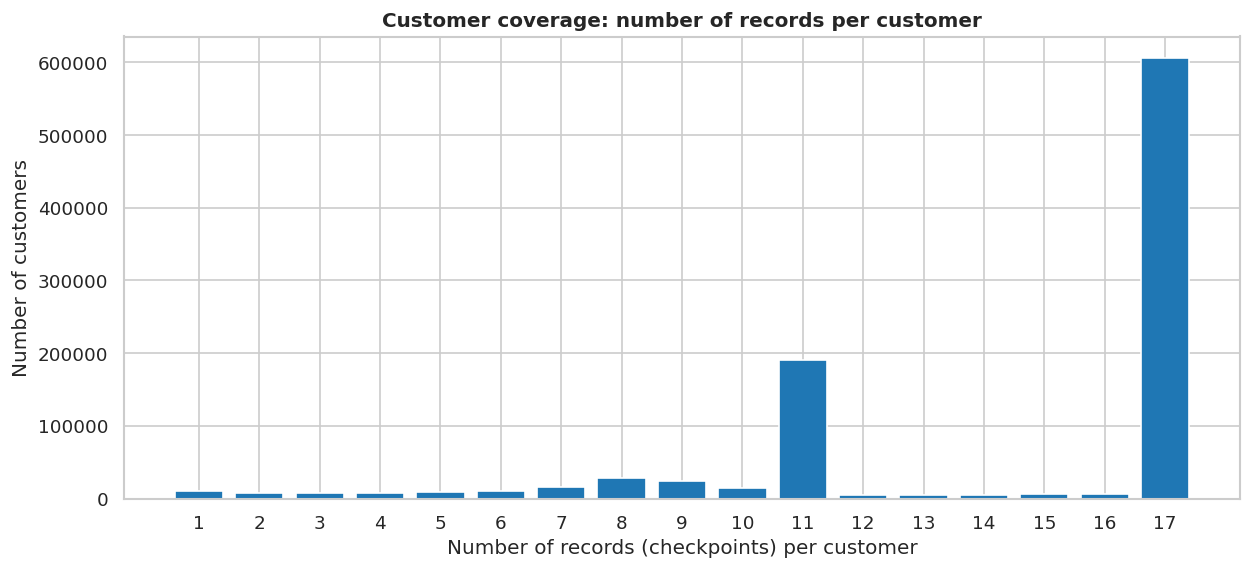

Customers with all 17 checkpoints: 63.3%


In [ ]:
# ## 3. Panel coverage EDA (independent of product acquisitions)
# Each bar answers: among all customers, how many have exactly N observed records?
records_per_customer = con.execute('''
    SELECT records::INTEGER AS record_count, COUNT(*)::INTEGER AS customer_count
    FROM (
        SELECT ncodpers, COUNT(*) AS records
        FROM read_parquet(?)
        GROUP BY ncodpers
    )
    GROUP BY records
    ORDER BY records
''', [str(TRAIN_PATH)]).fetchdf()

display(records_per_customer)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(records_per_customer['record_count'], records_per_customer['customer_count'], color='#1f77b4', width=0.8)
ax.set(title='Customer coverage: number of records per customer', xlabel='Number of records (checkpoints) per customer', ylabel='Number of customers')
ax.set_xticks(records_per_customer['record_count'])
ax.ticklabel_format(style='plain', axis='y')
plt.show()

full_history_share = records_per_customer.loc[records_per_customer.record_count.eq(records_per_customer.record_count.max()), 'customer_count'].sum() / records_per_customer.customer_count.sum()
print(f"Customers with all {records_per_customer.record_count.max()} checkpoints: {full_history_share:.1%}")


### Insights:
- Phần lớn người dùng sẽ có các 11 hoặc 17 records, lý do vì sao mà nó lại ngắt quãng như vậy, kiểu là sẽ k có 12, 13, 14, 15 hay 16 records; Nó có liên quan đến việc tăng dần số lượng user không?

 ## 4. Records by checkpoint month (independent of product acquisitions)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,checkpoint_month,record_count,customer_count
0,2015-01-28,625457,625457
1,2015-02-28,627394,627394
2,2015-03-28,629209,629209
3,2015-04-28,630367,630367
4,2015-05-28,631957,631957
5,2015-06-28,632110,632110
6,2015-07-28,829817,829817
7,2015-08-28,843201,843201
8,2015-09-28,865440,865440
9,2015-10-28,892251,892251


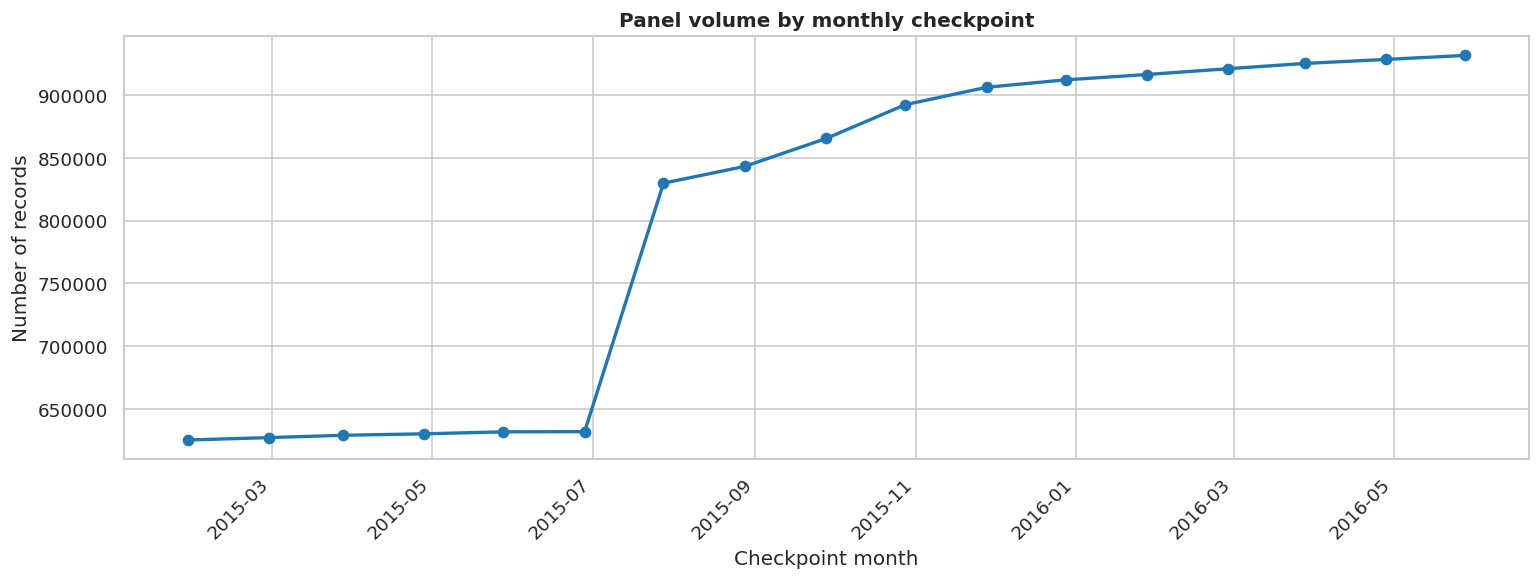

In [ ]:
# ## 4. Records by checkpoint month (independent of product acquisitions)
records_by_month = con.execute('''
    SELECT CAST(fecha_dato AS DATE) AS checkpoint_month, COUNT(*)::BIGINT AS record_count,
           COUNT(DISTINCT ncodpers)::BIGINT AS customer_count
    FROM read_parquet(?)
    GROUP BY fecha_dato
    ORDER BY fecha_dato
''', [str(TRAIN_PATH)]).fetchdf()

display(records_by_month)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(records_by_month['checkpoint_month'], records_by_month['record_count'], marker='o', color='#1f77b4', linewidth=2)
ax.set(title='Panel volume by monthly checkpoint', xlabel='Checkpoint month', ylabel='Number of records')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Insights:
- Trong giai đoạn từ tháng 7-2015 sang tháng 8-2015 thì có sự bùng nổ về số lượng record theo tháng -> có thêm một lượng lớn người dùng mới tại thời điểm 8/2015 -> điều này giải thích về việc tại sao số records theo người dùng lại có phân bố theo như hình trước đó.
- Người dùng từ sau 8/2015 sé có đúng thêm 11 record (hoàn toàn mới) và những người dùng đã có records trước đó thì cuối cùng sẽ có đủ 17 records.

## 5. Record-gap EDA: continuity of consecutive customer observations

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,gap_months,transition_count,customer_count
0,1,12682421,946089
1,2,2359,2282
2,3,1752,1737
3,4,1560,1560
4,5,1207,1206
5,6,1104,1104
6,7,66,66
7,8,42,42
8,9,35,35
9,10,35,35


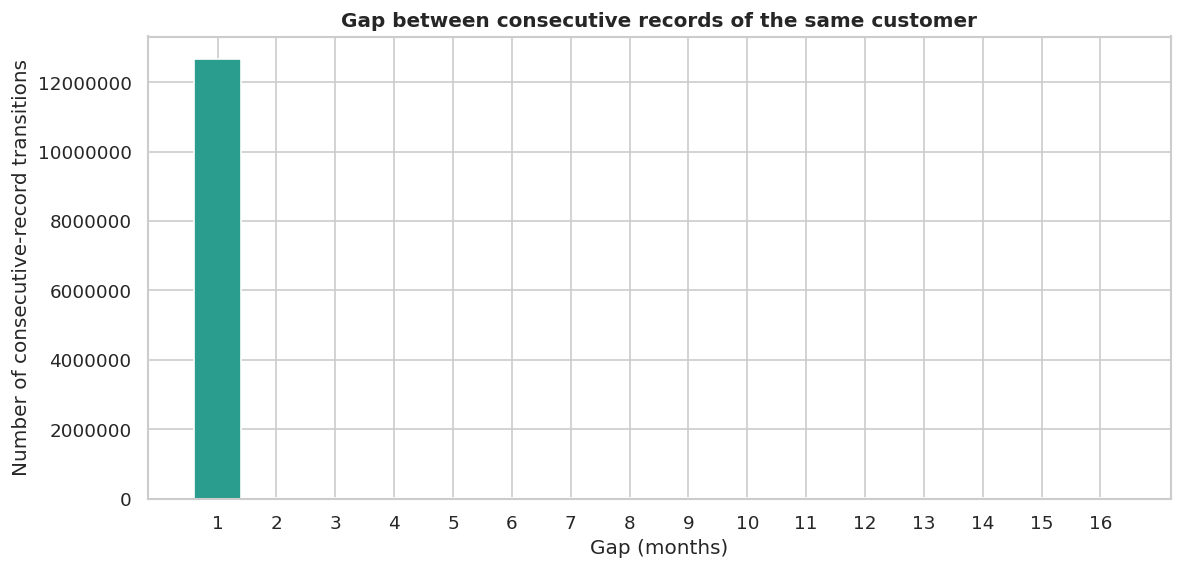

Continuous one-month transitions: 99.94% of all eligible transitions


In [ ]:
# ## 5. Record-gap EDA: continuity of consecutive customer observations
# A gap of 1 month is continuous. First records are excluded because no prior observation exists.
record_gaps = con.execute('''
    WITH ordered AS (
        SELECT ncodpers, CAST(fecha_dato AS DATE) AS checkpoint_month,
               LAG(CAST(fecha_dato AS DATE)) OVER (PARTITION BY ncodpers ORDER BY fecha_dato) AS previous_month
        FROM read_parquet(?)
    )
    SELECT date_diff('month', previous_month, checkpoint_month)::INTEGER AS gap_months,
           COUNT(*)::BIGINT AS transition_count,
           COUNT(DISTINCT ncodpers)::BIGINT AS customer_count
    FROM ordered
    WHERE previous_month IS NOT NULL
    GROUP BY gap_months
    ORDER BY gap_months
''', [str(TRAIN_PATH)]).fetchdf()

display(record_gaps)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(record_gaps['gap_months'].astype(str), record_gaps['transition_count'], color='#2a9d8f')
ax.set(title='Gap between consecutive records of the same customer', xlabel='Gap (months)', ylabel='Number of consecutive-record transitions')
ax.ticklabel_format(style='plain', axis='y')
plt.show()

continuous_share = record_gaps.loc[record_gaps.gap_months.eq(1), 'transition_count'].sum() / record_gaps.transition_count.sum()
print(f'Continuous one-month transitions: {continuous_share:.2%} of all eligible transitions')


### Insights:  
- Hầu hết các record của cùng customer đều liên tiếp nhau.
- Số lượng gap>1 khá là nhỏ va nếu cần thiết thì ta có thể tạo snapshot giả của record bị thiếu bằng records trước đó (nếu k có trước đó thì dùng lúc sau).

## 6. Temporal / cyclic EDA of acquisitions

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

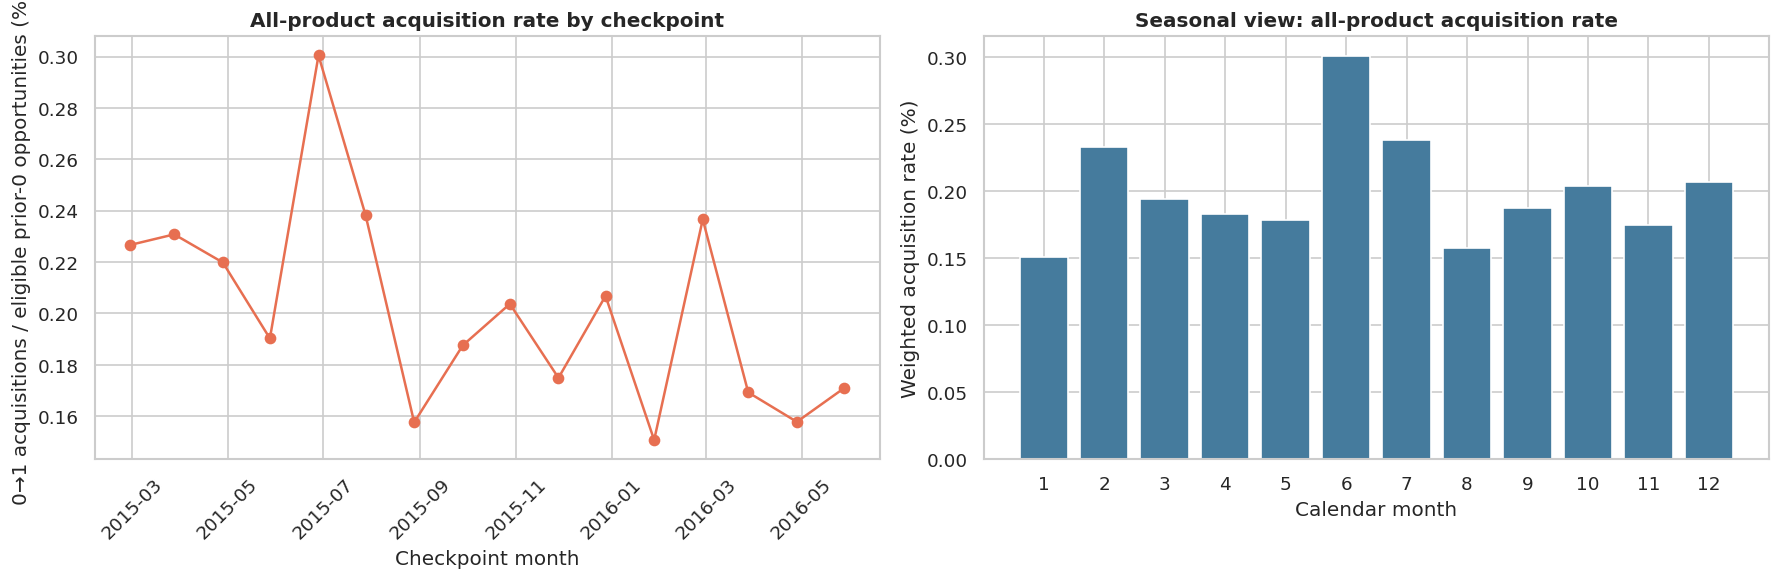

,checkpoint_month,acquisitions,eligible_prev_0,acquisition_rate
0,2015-01-28 00:00:00,0,0,nan%
1,2015-02-28 00:00:00,31372,13840999,0.2267%
2,2015-03-28 00:00:00,32062,13892989,0.2308%
3,2015-04-28 00:00:00,30617,13928117,0.2198%
4,2015-05-28 00:00:00,26553,13958210,0.1902%
5,2015-06-28 00:00:00,41991,13974905,0.3005%
6,2015-07-28 00:00:00,33713,14149306,0.2383%
7,2015-08-28 00:00:00,29514,18733773,0.1575%
8,2015-09-28 00:00:00,35731,19052488,0.1875%
9,2015-10-28 00:00:00,39834,19556557,0.2037%


,month_of_year,acquisitions,eligible_prev_0,acquisition_rate
0,1,31032,20596306,0.1507%
1,2,80444,34581177,0.2326%
2,3,67320,34730071,0.1938%
3,4,63639,34861739,0.1825%
4,5,62441,34966618,0.1786%
5,6,41991,13974905,0.3005%
6,7,33713,14149306,0.2383%
7,8,29514,18733773,0.1575%
8,9,35731,19052488,0.1875%
9,10,39834,19556557,0.2037%


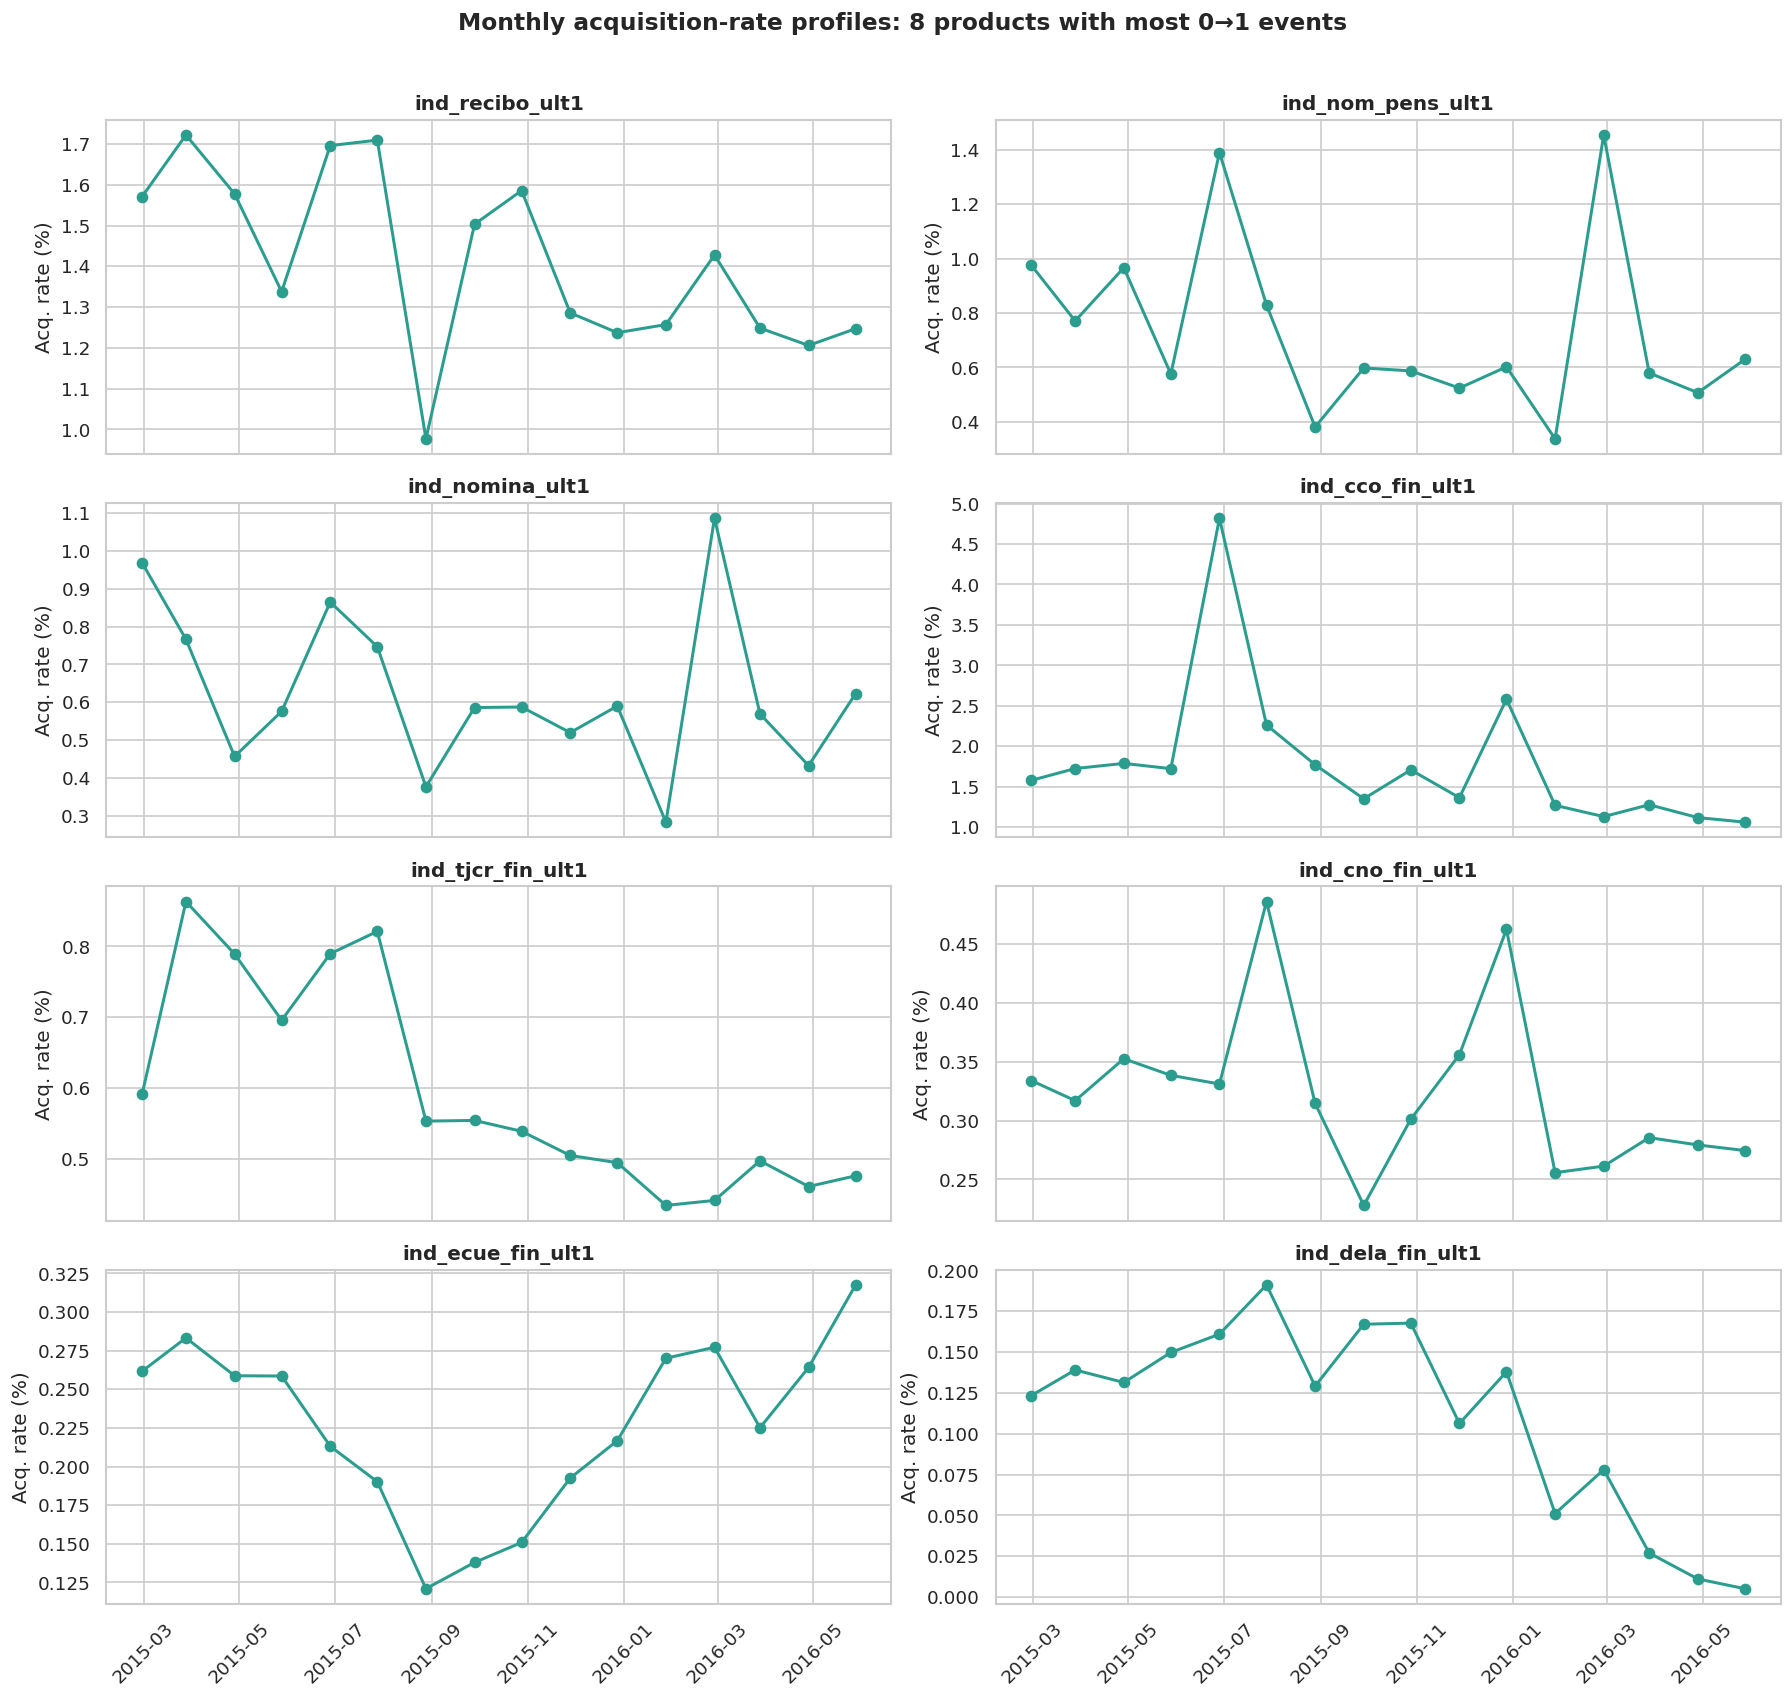

In [ ]:
# ## 6. Temporal / cyclic EDA of acquisitions
# Acquisition rate denominator:
# product-customer observations whose previous product state = 0.

# ------------------------------------------------------------
# 1. Build current and previous product states for each customer
# ------------------------------------------------------------

state_expressions = [
    'CAST(fecha_dato AS DATE) AS checkpoint_month',
    'LAG(fecha_dato) OVER customer_time AS previous_date',
]

for product in PRODUCT_COLUMNS:
    state_expressions += [
        f'COALESCE(CAST("{product}" AS INTEGER), 0) AS cur_{product}',
        f'COALESCE(LAG(CAST("{product}" AS INTEGER)) OVER customer_time, 0) AS prev_{product}',
    ]


# ------------------------------------------------------------
# 2. Count eligible opportunities and acquisitions by month
#
# eligible: previous state = 0
# acquisition: previous state = 0 AND current state = 1
# ------------------------------------------------------------

monthly_aggregate_expressions = []

for product in PRODUCT_COLUMNS:
    monthly_aggregate_expressions += [
        f"""
        SUM(
            CASE
                WHEN previous_date IS NOT NULL
                     AND prev_{product} = 0
                THEN 1 ELSE 0
            END
        )::BIGINT AS eligible_{product}
        """,
        f"""
        SUM(
            CASE
                WHEN previous_date IS NOT NULL
                     AND prev_{product} = 0
                     AND cur_{product} = 1
                THEN 1 ELSE 0
            END
        )::BIGINT AS acq_{product}
        """,
    ]


monthly_wide = con.execute(f'''
    WITH states AS (
        SELECT
            {', '.join(state_expressions)}
        FROM read_parquet('{str(TRAIN_PATH)}')
        WINDOW customer_time AS (
            PARTITION BY ncodpers
            ORDER BY fecha_dato
        )
    )

    SELECT
        checkpoint_month,
        {', '.join(monthly_aggregate_expressions)}
    FROM states
    GROUP BY checkpoint_month
    ORDER BY checkpoint_month
''').fetchdf()


# ------------------------------------------------------------
# 3. Convert wide table -> long table
#    One row = month × product
# ------------------------------------------------------------

monthly_rows = []

for _, row in monthly_wide.iterrows():
    for product in PRODUCT_COLUMNS:
        monthly_rows.append({
            'checkpoint_month': row['checkpoint_month'],
            'product': product,
            'eligible_prev_0': row[f'eligible_{product}'],
            'acquisitions': row[f'acq_{product}'],
        })

monthly_acquisition = pd.DataFrame(monthly_rows)

monthly_acquisition['acquisition_rate'] = (
    monthly_acquisition['acquisitions']
    / monthly_acquisition['eligible_prev_0'].replace(0, np.nan)
)


# ------------------------------------------------------------
# 4. Overall acquisition rate by checkpoint month
# ------------------------------------------------------------

all_product_monthly = (
    monthly_acquisition
    .groupby('checkpoint_month', as_index=False)
    .agg(
        acquisitions=('acquisitions', 'sum'),
        eligible_prev_0=('eligible_prev_0', 'sum'),
    )
)

all_product_monthly['acquisition_rate'] = (
    all_product_monthly['acquisitions']
    / all_product_monthly['eligible_prev_0']
)

all_product_monthly['month_of_year'] = (
    pd.to_datetime(all_product_monthly['checkpoint_month']).dt.month
)


# ------------------------------------------------------------
# 5. Seasonal acquisition rate
#    Same calendar months across years are combined.
# ------------------------------------------------------------

seasonal = (
    all_product_monthly
    .groupby('month_of_year', as_index=False)
    .agg(
        acquisitions=('acquisitions', 'sum'),
        eligible_prev_0=('eligible_prev_0', 'sum'),
    )
)

seasonal['acquisition_rate'] = (
    seasonal['acquisitions']
    / seasonal['eligible_prev_0']
)


# ------------------------------------------------------------
# 6. Plot overall temporal trend + seasonal view
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual timeline
axes[0].plot(
    all_product_monthly['checkpoint_month'],
    all_product_monthly['acquisition_rate'] * 100,
    marker='o',
    color='#e76f51',
)

axes[0].set(
    title='All-product acquisition rate by checkpoint',
    xlabel='Checkpoint month',
    ylabel='0→1 acquisitions / eligible prior-0 opportunities (%)',
)

axes[0].tick_params(axis='x', rotation=45)


# Calendar-month seasonality
axes[1].bar(
    seasonal['month_of_year'].astype(str),
    seasonal['acquisition_rate'] * 100,
    color='#457b9d',
)

axes[1].set(
    title='Seasonal view: all-product acquisition rate',
    xlabel='Calendar month',
    ylabel='Weighted acquisition rate (%)',
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Display aggregate tables
# ------------------------------------------------------------

display(
    all_product_monthly[
        [
            'checkpoint_month',
            'acquisitions',
            'eligible_prev_0',
            'acquisition_rate',
        ]
    ].style.format({
        'acquisition_rate': '{:.4%}'
    })
)

display(
    seasonal.style.format({
        'acquisition_rate': '{:.4%}'
    })
)


# ------------------------------------------------------------
# 8. Product-level temporal profiles
#    Select 8 products with the most 0→1 acquisitions
# ------------------------------------------------------------

top_products = (
    monthly_acquisition
    .groupby('product', as_index=False)['acquisitions']
    .sum()
    .nlargest(8, 'acquisitions')['product']
    .tolist()
)

fig, axes = plt.subplots(
    4,
    2,
    figsize=(15, 14),
    sharex=True,
)

for ax, product in zip(axes.flat, top_products):

    data = (
        monthly_acquisition[
            monthly_acquisition['product'].eq(product)
        ]
        .sort_values('checkpoint_month')
    )

    ax.plot(
        data['checkpoint_month'],
        data['acquisition_rate'] * 100,
        marker='o',
        linewidth=1.8,
        color='#2a9d8f',
    )

    ax.set_title(product)
    ax.set_ylabel('Acq. rate (%)')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(
    'Monthly acquisition-rate profiles: 8 products with most 0→1 events',
    y=1.01,
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.show()

### Insights:
- một số product có biểu đồ mua mới tương đồng với nhau.
Cách encode cho dữ liệu datime vẫn chưa biết vì ở global thì không hè có yếu tố theo thời gian, theo chu kì như kì vọng.

## 7. Panel and temporal summary

In [ ]:
# ## 7. Panel and temporal summary
# Compact, executed facts. Per-product transition counts and imbalance are shown in the next cell.
print('Panel size:', f"{panel_overview.loc[0, 'records']:,} records | {panel_overview.loc[0, 'customers']:,} customers | {panel_overview.loc[0, 'checkpoints']} checkpoints")
print('Full-history customers:', f'{full_history_share:.1%}')
print('Continuous monthly record transitions:', f'{continuous_share:.2%}')
print('\nAll-product acquisition rate by checkpoint:')
display(all_product_monthly[['checkpoint_month', 'acquisition_rate']].style.format({'acquisition_rate': '{:.4%}'}))


Panel size: 13,647,309 records | 956,645 customers | 17 checkpoints
Full-history customers: 63.3%
Continuous monthly record transitions: 99.94%

All-product acquisition rate by checkpoint:


,checkpoint_month,acquisition_rate
0,2015-01-28 00:00:00,nan%
1,2015-02-28 00:00:00,0.2267%
2,2015-03-28 00:00:00,0.2308%
3,2015-04-28 00:00:00,0.2198%
4,2015-05-28 00:00:00,0.1902%
5,2015-06-28 00:00:00,0.3005%
6,2015-07-28 00:00:00,0.2383%
7,2015-08-28 00:00:00,0.1575%
8,2015-09-28 00:00:00,0.1875%
9,2015-10-28 00:00:00,0.2037%


### Insights:
- Nhìn qua thì ta thấy acquisition giữa các tháng/checkpoint có độ ổn định tuowg đối (duy trì ở mức 0.15-0.21)

## 8. Acquisition targets: 4 transition cases and per-product class imbalance

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

transition,product,0->0,0->1,1->0,1->1,train_samples_prev_0,positive_rate_0_to_1,negative_to_positive_ratio
0,ind_cco_fin_ult1,4237338,69997,89644,8293685,4307335,1.6251%,60.5:1
1,ind_recibo_ult1,10905349,153205,136594,1495516,11058554,1.3854%,71.2:1
2,ind_nom_pens_ult1,11848734,84768,76112,681050,11933502,0.7103%,139.8:1
3,ind_nomina_ult1,11919277,73800,65329,632258,11993077,0.6154%,161.5:1
4,ind_tjcr_fin_ult1,12050410,69311,70449,500494,12119721,0.5719%,173.9:1
5,ind_cno_fin_ult1,11622967,37187,23846,1006664,11660154,0.3189%,312.6:1
6,ind_ecue_fin_ult1,11611005,26378,11035,1042246,11637383,0.2267%,440.2:1
7,ind_dela_fin_ult1,12122796,12707,18515,536646,12135503,0.1047%,954.0:1
8,ind_reca_fin_ult1,12012001,9238,11,669414,12021239,0.0768%,"1,300.3:1"
9,ind_ctma_fin_ult1,12559023,7002,10021,114618,12566025,0.0557%,"1,793.6:1"


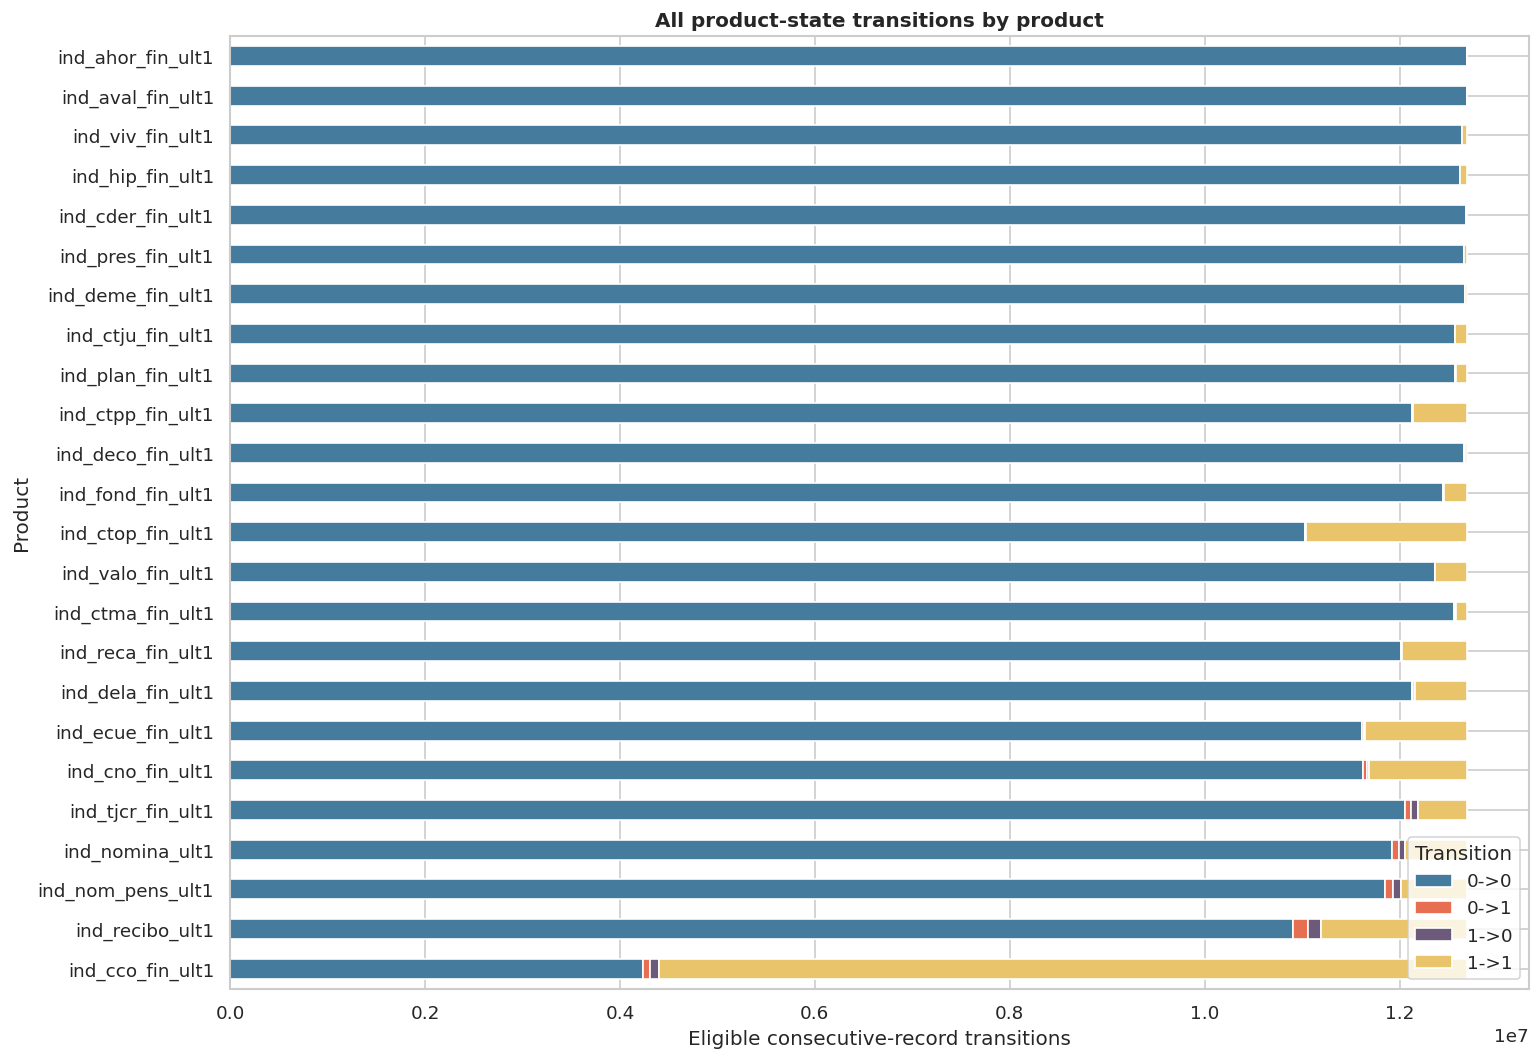

Acquisition-model imbalance (previous state = 0 only):


transition,product,train_samples_prev_0,0->0,0->1,positive_rate_0_to_1,negative_to_positive_ratio
0,ind_cco_fin_ult1,4307335,4237338,69997,1.625065e-02,6.053599e+01
1,ind_recibo_ult1,11058554,10905349,153205,1.385398e-02,7.118142e+01
2,ind_nom_pens_ult1,11933502,11848734,84768,7.103363e-03,1.397784e+02
3,ind_nomina_ult1,11993077,11919277,73800,6.153550e-03,1.615078e+02
4,ind_tjcr_fin_ult1,12119721,12050410,69311,5.718861e-03,1.738600e+02
5,ind_cno_fin_ult1,11660154,11622967,37187,3.189237e-03,3.125546e+02
6,ind_ecue_fin_ult1,11637383,11611005,26378,2.266661e-03,4.401776e+02
7,ind_dela_fin_ult1,12135503,12122796,12707,1.047093e-03,9.540250e+02
8,ind_reca_fin_ult1,12021239,12012001,9238,7.684732e-04,1.300282e+03
9,ind_ctma_fin_ult1,12566025,12559023,7002,5.572168e-04,1.793634e+03


In [ ]:
# ## 8. Acquisition targets: 4 transition cases and per-product class imbalance
# Training eligibility for an acquisition model is previous_state = 0:
#   negative label: 0 -> 0; positive label: 0 -> 1.
# States beginning at 1 are printed as data-quality/business context, but are excluded from that product's acquisition-training candidates.
def quote_identifier(name: str) -> str:
    return '"' + name.replace('"', '""') + '"'

transition_queries = []
for product in PRODUCT_COLUMNS:
    p = quote_identifier(product)
    transition_queries.append(f'''
        SELECT '{product}' AS product,
               CASE
                   WHEN previous_state = 0 AND current_state = 0 THEN '0->0'
                   WHEN previous_state = 0 AND current_state = 1 THEN '0->1'
                   WHEN previous_state = 1 AND current_state = 0 THEN '1->0'
                   WHEN previous_state = 1 AND current_state = 1 THEN '1->1'
               END AS transition,
               COUNT(*)::BIGINT AS samples
        FROM (
            SELECT COALESCE(LAG(CAST({p} AS INTEGER)) OVER customer_time, 0) AS previous_state,
                   COALESCE(CAST({p} AS INTEGER), 0) AS current_state,
                   LAG(fecha_dato) OVER customer_time AS previous_date
            FROM read_parquet('{str(TRAIN_PATH)}')
            WINDOW customer_time AS (PARTITION BY ncodpers ORDER BY fecha_dato)
        ) states
        WHERE previous_date IS NOT NULL
        GROUP BY ALL
    ''')

transition_long = con.execute('\nUNION ALL\n'.join(transition_queries)).fetchdf()
transition_summary = (
    transition_long.pivot(index='product', columns='transition', values='samples')
    .fillna(0).astype('int64').reset_index()
)
for state in ['0->0', '0->1', '1->0', '1->1']:
    if state not in transition_summary:
        transition_summary[state] = 0
transition_summary = transition_summary[['product', '0->0', '0->1', '1->0', '1->1']]
transition_summary['train_samples_prev_0'] = transition_summary['0->0'] + transition_summary['0->1']
transition_summary['positive_rate_0_to_1'] = transition_summary['0->1'] / transition_summary['train_samples_prev_0']
transition_summary['negative_to_positive_ratio'] = transition_summary['0->0'] / transition_summary['0->1'].replace(0, np.nan)
transition_summary = transition_summary.sort_values('positive_rate_0_to_1', ascending=False).reset_index(drop=True)

display(transition_summary.style.format({'positive_rate_0_to_1': '{:.4%}', 'negative_to_positive_ratio': '{:,.1f}:1'}))

fig, ax = plt.subplots(figsize=(13, 9))
plot_data = transition_summary.set_index('product')[['0->0', '0->1', '1->0', '1->1']]
plot_data.plot(kind='barh', stacked=True, ax=ax, color=['#457b9d', '#e76f51', '#6d597a', '#e9c46a'])
ax.set(title='All product-state transitions by product', xlabel='Eligible consecutive-record transitions', ylabel='Product')
ax.legend(title='Transition', loc='lower right')
plt.tight_layout()
plt.show()

print('Acquisition-model imbalance (previous state = 0 only):')
display(transition_summary[['product', 'train_samples_prev_0', '0->0', '0->1', 'positive_rate_0_to_1', 'negative_to_positive_ratio']])


### Insights:
- Dựa vào biểu đồ và bảng thống kê, dữ liệu siêu mất cân bằng, nếu thực hiện bài toán dự đoán nhãn 0/1 nếu trạng thái trước đó là 0 thì ta thấy ở nhãn chueyenr từ 0->1 chiếm tỉ lệ và số lượng rất nhỏ so với nhãn chuyển từ 0->0;
- Cần phải giải quyết vấn đề này trước khi thực hiện.
- Vấn đề là, metrics không phạt nếu như recommend dư, metrics chỉ phạt nếu như recommend thiếu và các sản phẩm đúng k nằm ở cao nhất.
- Dữ liệu ở mỗi model là khác nhau, có phân bố khác nhau. Nên là không thể thực hiện so sánh trực tiếp xs giữa các product với nhau, hoặc là có cơ chế weighted để train.

## 9. KFM (RFM-proxy) raw features and lifecycle EDA

**Giả định:** project chỉ định nghĩa RFM-proxy; trong section này, `kfm_*` được dùng theo yêu cầu và có nghĩa RFM-proxy. Không chia tier. Artifact chỉ phục vụ EDA được ghi vào `/content/santander_eda/` của Colab (ephemeral).

In [ ]:
# ## 9.1 Create raw KFM (RFM-proxy) and lifecycle signals for EDA only
# Output is intentionally written to Colab's ephemeral /content, not Drive or the project repository.
from pathlib import Path

EDA_OUTPUT_DIR = Path('/content/santander_eda')
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
KFM_LIFECYCLE_PATH = EDA_OUTPUT_DIR / 'kfm_lifecycle_raw.parquet'

q = lambda name: '"' + name.replace('"', '""') + '"'
product_state_sum = ' + '.join(f'COALESCE(CAST({q(product)} AS INTEGER), 0)' for product in PRODUCT_COLUMNS)
acquisition_terms = ',\n               '.join(
    f"CASE WHEN LAG(fecha_dato) OVER customer_time IS NOT NULL "
    f"AND COALESCE(LAG(CAST({q(product)} AS INTEGER)) OVER customer_time, 0) = 0 "
    f"AND COALESCE(CAST({q(product)} AS INTEGER), 0) = 1 THEN 1 ELSE 0 END"
    for product in PRODUCT_COLUMNS
)

con.execute(f'''
    COPY (
        WITH monthly_state AS (
            SELECT
                ncodpers,
                CAST(fecha_dato AS DATE) AS checkpoint_month,
                {product_state_sum} AS kfm_monetary_product_count,
                ({' + '.join(acquisition_terms.split(',\n               '))}) AS acquisitions_this_month,
                LAG(CAST(fecha_dato AS DATE)) OVER customer_time AS previous_month,
                LEAD(CAST(fecha_dato AS DATE)) OVER customer_time AS next_month,
                TRY_CAST(ind_actividad_cliente AS INTEGER) AS activity_flag,
                TRY_CAST(indfall AS INTEGER) AS deceased_flag
            FROM read_parquet('{str(TRAIN_PATH)}')
            WINDOW customer_time AS (PARTITION BY ncodpers ORDER BY fecha_dato)
        ),
        kfm_history AS (
            SELECT
                *,
                MIN(checkpoint_month) OVER customer_time AS customer_first_observed_month,
                SUM(acquisitions_this_month) OVER customer_time AS kfm_frequency_lifetime,
                MAX(CASE WHEN acquisitions_this_month > 0 THEN checkpoint_month END) OVER customer_time AS kfm_last_acquisition_month
            FROM monthly_state
            WINDOW customer_time AS (
                PARTITION BY ncodpers ORDER BY checkpoint_month
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            )
        )
        SELECT
            ncodpers,
            checkpoint_month,
            kfm_monetary_product_count,
            acquisitions_this_month,
            kfm_frequency_lifetime,
            date_diff('month', kfm_last_acquisition_month, checkpoint_month)::INTEGER AS kfm_recency_months,
            date_diff('month', customer_first_observed_month, checkpoint_month)::INTEGER AS customer_history_months,
            date_diff('month', previous_month, checkpoint_month)::INTEGER AS record_gap_months,
            date_diff('month', checkpoint_month, next_month)::INTEGER AS next_record_gap_months_eda_only,
            CAST(next_month IS NULL AS INTEGER) AS is_final_observed_record_eda_only,
            activity_flag,
            deceased_flag
        FROM kfm_history
    ) TO '{str(KFM_LIFECYCLE_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)
''')

print(f'Wrote raw KFM/lifecycle EDA artifact: {KFM_LIFECYCLE_PATH}')
print(f'Artifact size: {KFM_LIFECYCLE_PATH.stat().st_size / 1e6:.1f} MB')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Wrote raw KFM/lifecycle EDA artifact: /content/santander_eda/kfm_lifecycle_raw.parquet
Artifact size: 10.8 MB


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,records,customers,mean_products_owned,p50_products_owned,p50_lifetime_acquisitions,p90_lifetime_acquisitions,mean_recency_observed,no_acquisition_yet_records
0,13647309,956645,1.462021,1.0,0.0,1.0,3.159944,11604407


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,recency_segment,records,customers,activity_flag_rate,mean_products_owned,mean_lifetime_acquisitions,mean_acquisitions_this_month,next_month_absence_rate_eda_only
0,new_history_0_2m,2836716,956645,42.46%,1.30,0.06,0.0397,0.18%
1,never_acquired,8900506,830624,36.89%,1.17,0.00,0.0000,0.03%
2,acquired_this_month,359976,170283,96.55%,3.70,3.05,1.2521,0.03%
3,recent_1_2m,613187,192935,94.41%,3.14,2.59,0.0000,0.07%
4,aging_3_5m,514442,167801,89.59%,2.85,2.06,0.0000,0.04%
5,dormant_6m_plus,422482,103647,85.28%,2.66,1.59,0.0000,0.01%


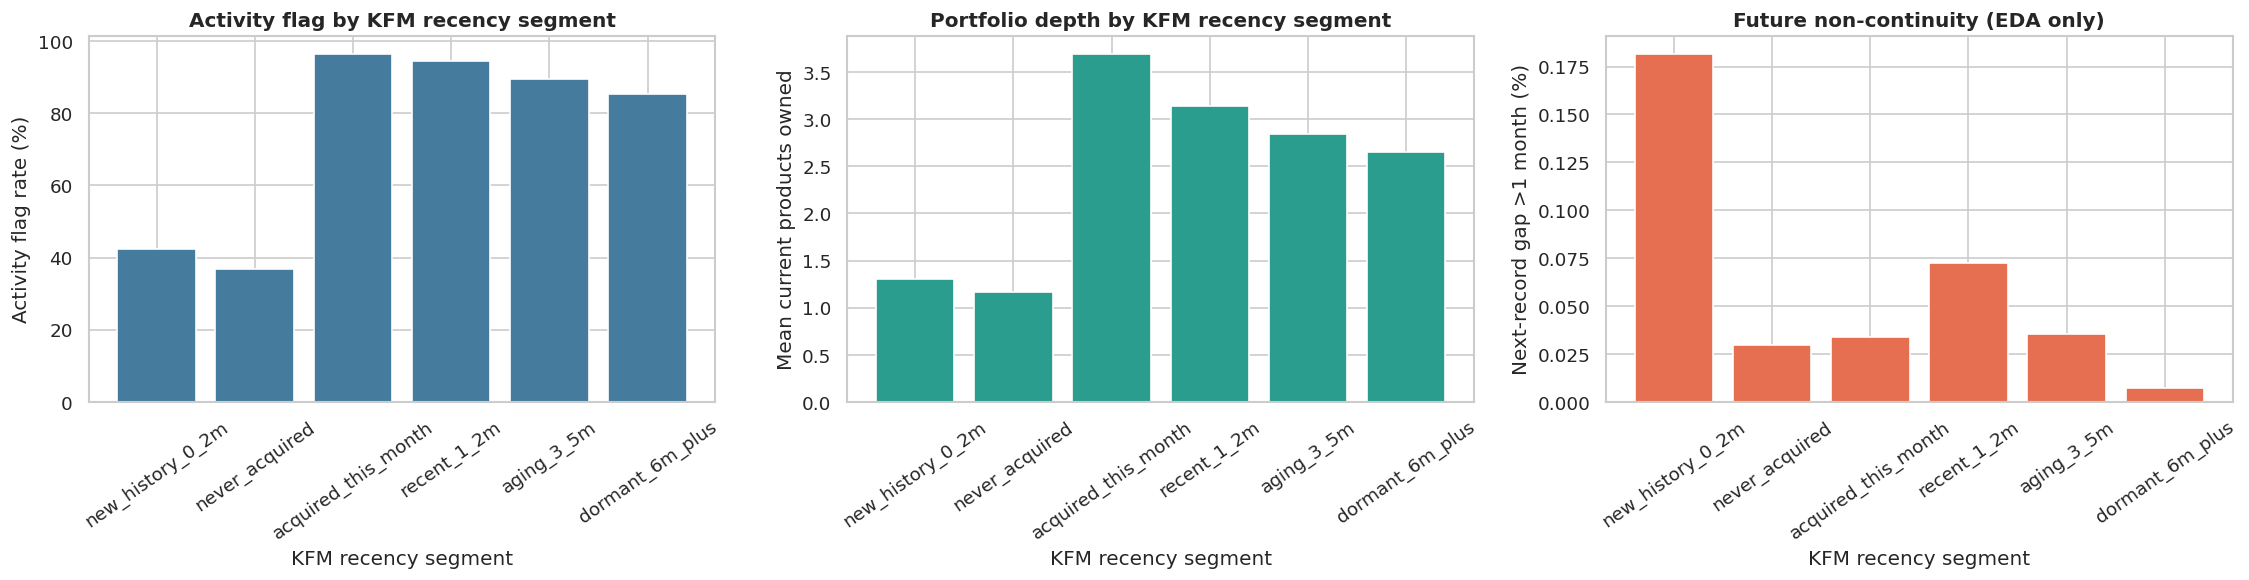

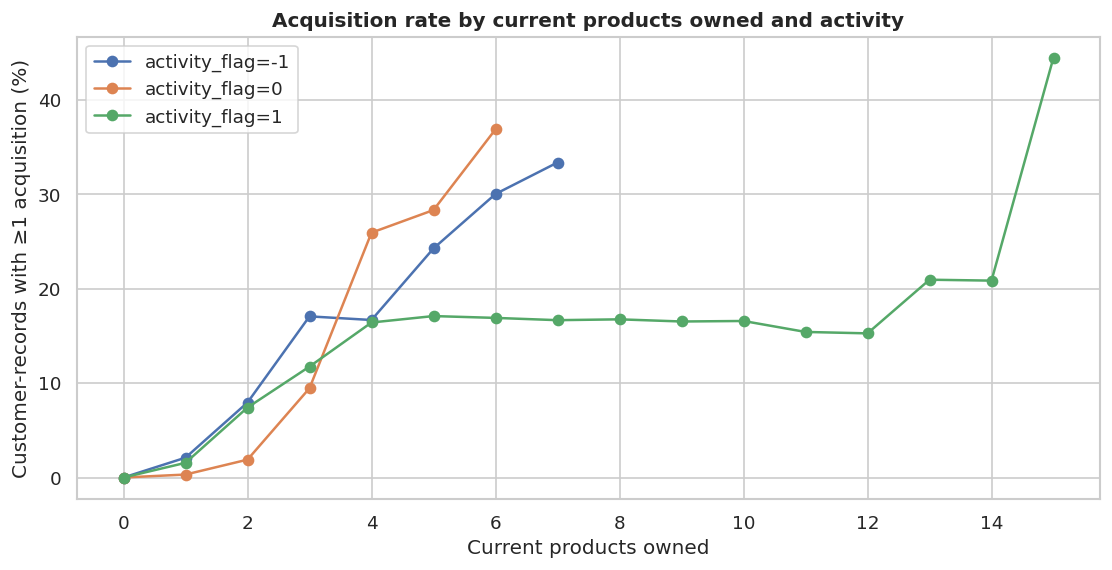

,activity_flag,products_owned,records,acquisition_rate
0,-1,0,4218,0.00%
1,-1,1,14249,2.10%
2,-1,2,1550,7.94%
3,-1,3,217,17.05%
4,-1,4,96,16.67%
5,-1,5,33,24.24%
6,-1,6,10,30.00%
7,-1,7,9,33.33%
8,0,0,2278365,0.00%
9,0,1,4223397,0.31%


In [ ]:
# ## 9.2 EDA: KFM relationships and evidence for lifecycle boundaries
kfm_overview = con.execute('''
    SELECT
        COUNT(*) AS records,
        COUNT(DISTINCT ncodpers) AS customers,
        AVG(kfm_monetary_product_count) AS mean_products_owned,
        quantile_cont(kfm_monetary_product_count, 0.50) AS p50_products_owned,
        quantile_cont(kfm_frequency_lifetime, 0.50) AS p50_lifetime_acquisitions,
        quantile_cont(kfm_frequency_lifetime, 0.90) AS p90_lifetime_acquisitions,
        AVG(kfm_recency_months) FILTER (WHERE kfm_recency_months IS NOT NULL) AS mean_recency_observed,
        SUM(kfm_recency_months IS NULL)::BIGINT AS no_acquisition_yet_records
    FROM read_parquet(?)
''', [str(KFM_LIFECYCLE_PATH)]).fetchdf()
display(kfm_overview)

# Treat absent product acquisition as its own state; it is not equivalent to a high numeric recency.
lifecycle_evidence = con.execute('''
    WITH base AS (
        SELECT *,
            CASE
                WHEN deceased_flag = 1 THEN 'deceased_flag'
                WHEN customer_history_months <= 2 THEN 'new_history_0_2m'
                WHEN kfm_recency_months IS NULL THEN 'never_acquired'
                WHEN kfm_recency_months = 0 THEN 'acquired_this_month'
                WHEN kfm_recency_months BETWEEN 1 AND 2 THEN 'recent_1_2m'
                WHEN kfm_recency_months BETWEEN 3 AND 5 THEN 'aging_3_5m'
                ELSE 'dormant_6m_plus'
            END AS recency_segment,
            CASE
                WHEN next_record_gap_months_eda_only > 1 THEN 1
                WHEN next_record_gap_months_eda_only = 1 THEN 0
                ELSE NULL
            END AS future_gap_after_current_eda_only
        FROM read_parquet(?)
    )
    SELECT
        recency_segment,
        COUNT(*)::BIGINT AS records,
        COUNT(DISTINCT ncodpers)::BIGINT AS customers,
        AVG(COALESCE(activity_flag, 0)) AS activity_flag_rate,
        AVG(kfm_monetary_product_count) AS mean_products_owned,
        AVG(kfm_frequency_lifetime) AS mean_lifetime_acquisitions,
        AVG(acquisitions_this_month) AS mean_acquisitions_this_month,
        AVG(future_gap_after_current_eda_only) AS next_month_absence_rate_eda_only
    FROM base
    GROUP BY recency_segment
    ORDER BY CASE recency_segment
        WHEN 'deceased_flag' THEN 0 WHEN 'new_history_0_2m' THEN 1 WHEN 'never_acquired' THEN 2
        WHEN 'acquired_this_month' THEN 3 WHEN 'recent_1_2m' THEN 4 WHEN 'aging_3_5m' THEN 5 ELSE 6 END
''', [str(KFM_LIFECYCLE_PATH)]).fetchdf()
display(lifecycle_evidence.style.format({
    'activity_flag_rate': '{:.2%}', 'mean_acquisitions_this_month': '{:.4f}',
    'next_month_absence_rate_eda_only': '{:.2%}', 'mean_products_owned': '{:.2f}',
    'mean_lifetime_acquisitions': '{:.2f}'
}))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
plot_evidence = lifecycle_evidence[lifecycle_evidence.recency_segment.ne('deceased_flag')]
axes[0].bar(plot_evidence.recency_segment, plot_evidence.activity_flag_rate * 100, color='#457b9d')
axes[0].set(title='Activity flag by KFM recency segment', ylabel='Activity flag rate (%)', xlabel='KFM recency segment')
axes[1].bar(plot_evidence.recency_segment, plot_evidence.mean_products_owned, color='#2a9d8f')
axes[1].set(title='Portfolio depth by KFM recency segment', ylabel='Mean current products owned', xlabel='KFM recency segment')
axes[2].bar(plot_evidence.recency_segment, plot_evidence.next_month_absence_rate_eda_only * 100, color='#e76f51')
axes[2].set(title='Future non-continuity (EDA only)', ylabel='Next-record gap >1 month (%)', xlabel='KFM recency segment')
for ax in axes:
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

# Relationship of activity and product-event intensity; excludes first observations only for a comparable gap population.
# Relationship between current portfolio size, activity, and acquisition probability.
# Only consecutive monthly records are used.
activity_relationship = con.execute('''
    SELECT
        COALESCE(activity_flag, -1) AS activity_flag,
        kfm_monetary_product_count AS products_owned,
        COUNT(*)::BIGINT AS records,

        AVG(
            CASE
                WHEN acquisitions_this_month > 0 THEN 1.0
                ELSE 0.0
            END
        ) AS acquisition_rate

    FROM read_parquet(?)

    WHERE record_gap_months = 1

    GROUP BY
        activity_flag,
        products_owned

    ORDER BY
        activity_flag,
        products_owned
''', [str(KFM_LIFECYCLE_PATH)]).fetchdf()


# Plot
fig, ax = plt.subplots(figsize=(11, 5))

for activity_value, group in activity_relationship.groupby('activity_flag'):
    ax.plot(
        group['products_owned'],
        group['acquisition_rate'] * 100,
        marker='o',
        label=f'activity_flag={activity_value}'
    )

ax.set(
    title='Acquisition rate by current products owned and activity',
    xlabel='Current products owned',
    ylabel='Customer-records with ≥1 acquisition (%)'
)

ax.legend()
plt.show()


# Show sample size as well
display(
    activity_relationship.style.format({
        'acquisition_rate': '{:.2%}'
    })
)


### Insights:
- Sơ đồ dưới: customer sở hữu càng nhiều sản phẩm thì sẽ càng có tỉ lệ mua thêm mới càng cao hơn (và nó có bị ảnh hưởng bởi active_flag). -> **Tạo feature `n_prods_owned` là số products mà customer này sở hữu.**
- Sơ đồ trên: Ta thấy khi phân theo nhóm 1-2 months, 3-5 months, 6+ months thì khi số rencency_months tăng lên thì số `activity_flag_rate` (feature `ind_actividad_cliente`) và `mean_products_owned` có xu hướng giảm dần, cho thấy recency có chứa thông tin liên quan tới hành vi, trạng thái của customer.
- SƠ đồ trên: Tuy ta thấy khi tăng dần recency_months thì tỉ lệ ind_actividad_cliente=1 cũng giảm dần, tuy nhiên nó chỉ giảm về tỉ lệ chứ k trực tiếp quyết định hay tuyệt đối ở một ngưỡng recency_months nào đó nên là ta sẽ **giữ cả hai feature recency_months và ind_actividad_cliente**

In [ ]:
# ## KFM Recency EDA by exact recency month
# One row = one exact value of kfm_recency_months

recency_month_evidence = con.execute('''
    SELECT
        CAST(kfm_recency_months AS INTEGER) AS recency_months,

        COUNT(*)::BIGINT AS records,
        COUNT(DISTINCT ncodpers)::BIGINT AS customers,

        -- Original Santander feature: ind_actividad_cliente
        AVG(activity_flag) AS activity_rate,

        -- M: current number of products owned
        AVG(kfm_monetary_product_count) AS mean_products_owned,

        -- F: cumulative observed 0→1 acquisitions
        AVG(kfm_frequency_lifetime) AS mean_lifetime_acquisitions,

        -- Number of acquisitions in the current month
        AVG(acquisitions_this_month) AS mean_acquisitions_this_month,

        -- EDA only: whether the next observed record is >1 month away
        AVG(
            CASE
                WHEN next_record_gap_months_eda_only > 1 THEN 1.0
                WHEN next_record_gap_months_eda_only = 1 THEN 0.0
                ELSE NULL
            END
        ) AS next_month_absence_rate_eda_only

    FROM read_parquet(?)

    -- NULL means no observed acquisition yet, so exclude it here
    WHERE kfm_recency_months IS NOT NULL

    GROUP BY kfm_recency_months
    ORDER BY kfm_recency_months
''', [str(KFM_LIFECYCLE_PATH)]).fetchdf()


display(
    recency_month_evidence.style.format({
        'activity_rate': '{:.2%}',
        'mean_products_owned': '{:.2f}',
        'mean_lifetime_acquisitions': '{:.2f}',
        'mean_acquisitions_this_month': '{:.4f}',
        'next_month_absence_rate_eda_only': '{:.3%}',
    })
)

,recency_months,records,customers,activity_rate,mean_products_owned,mean_lifetime_acquisitions,mean_acquisitions_this_month,next_month_absence_rate_eda_only
0,0,447903,202332,95.40%,3.54,2.72,1.2577,0.061%
1,1,371720,194719,94.41%,3.15,2.58,0.0000,0.107%
2,2,286355,184275,93.37%,3.02,2.40,0.0000,0.058%
3,3,214855,167535,91.03%,2.93,2.21,0.0000,0.069%
4,4,165113,146708,89.24%,2.81,2.00,0.0000,0.012%
5,5,134474,126823,87.81%,2.75,1.89,0.0000,0.010%
6,6,105489,103616,86.67%,2.72,1.78,0.0000,0.007%
7,7,85390,85084,85.87%,2.67,1.70,0.0000,0.014%
8,8,64785,64785,85.35%,2.63,1.60,0.0000,0.007%
9,9,50969,50969,84.76%,2.62,1.52,0.0000,0.005%


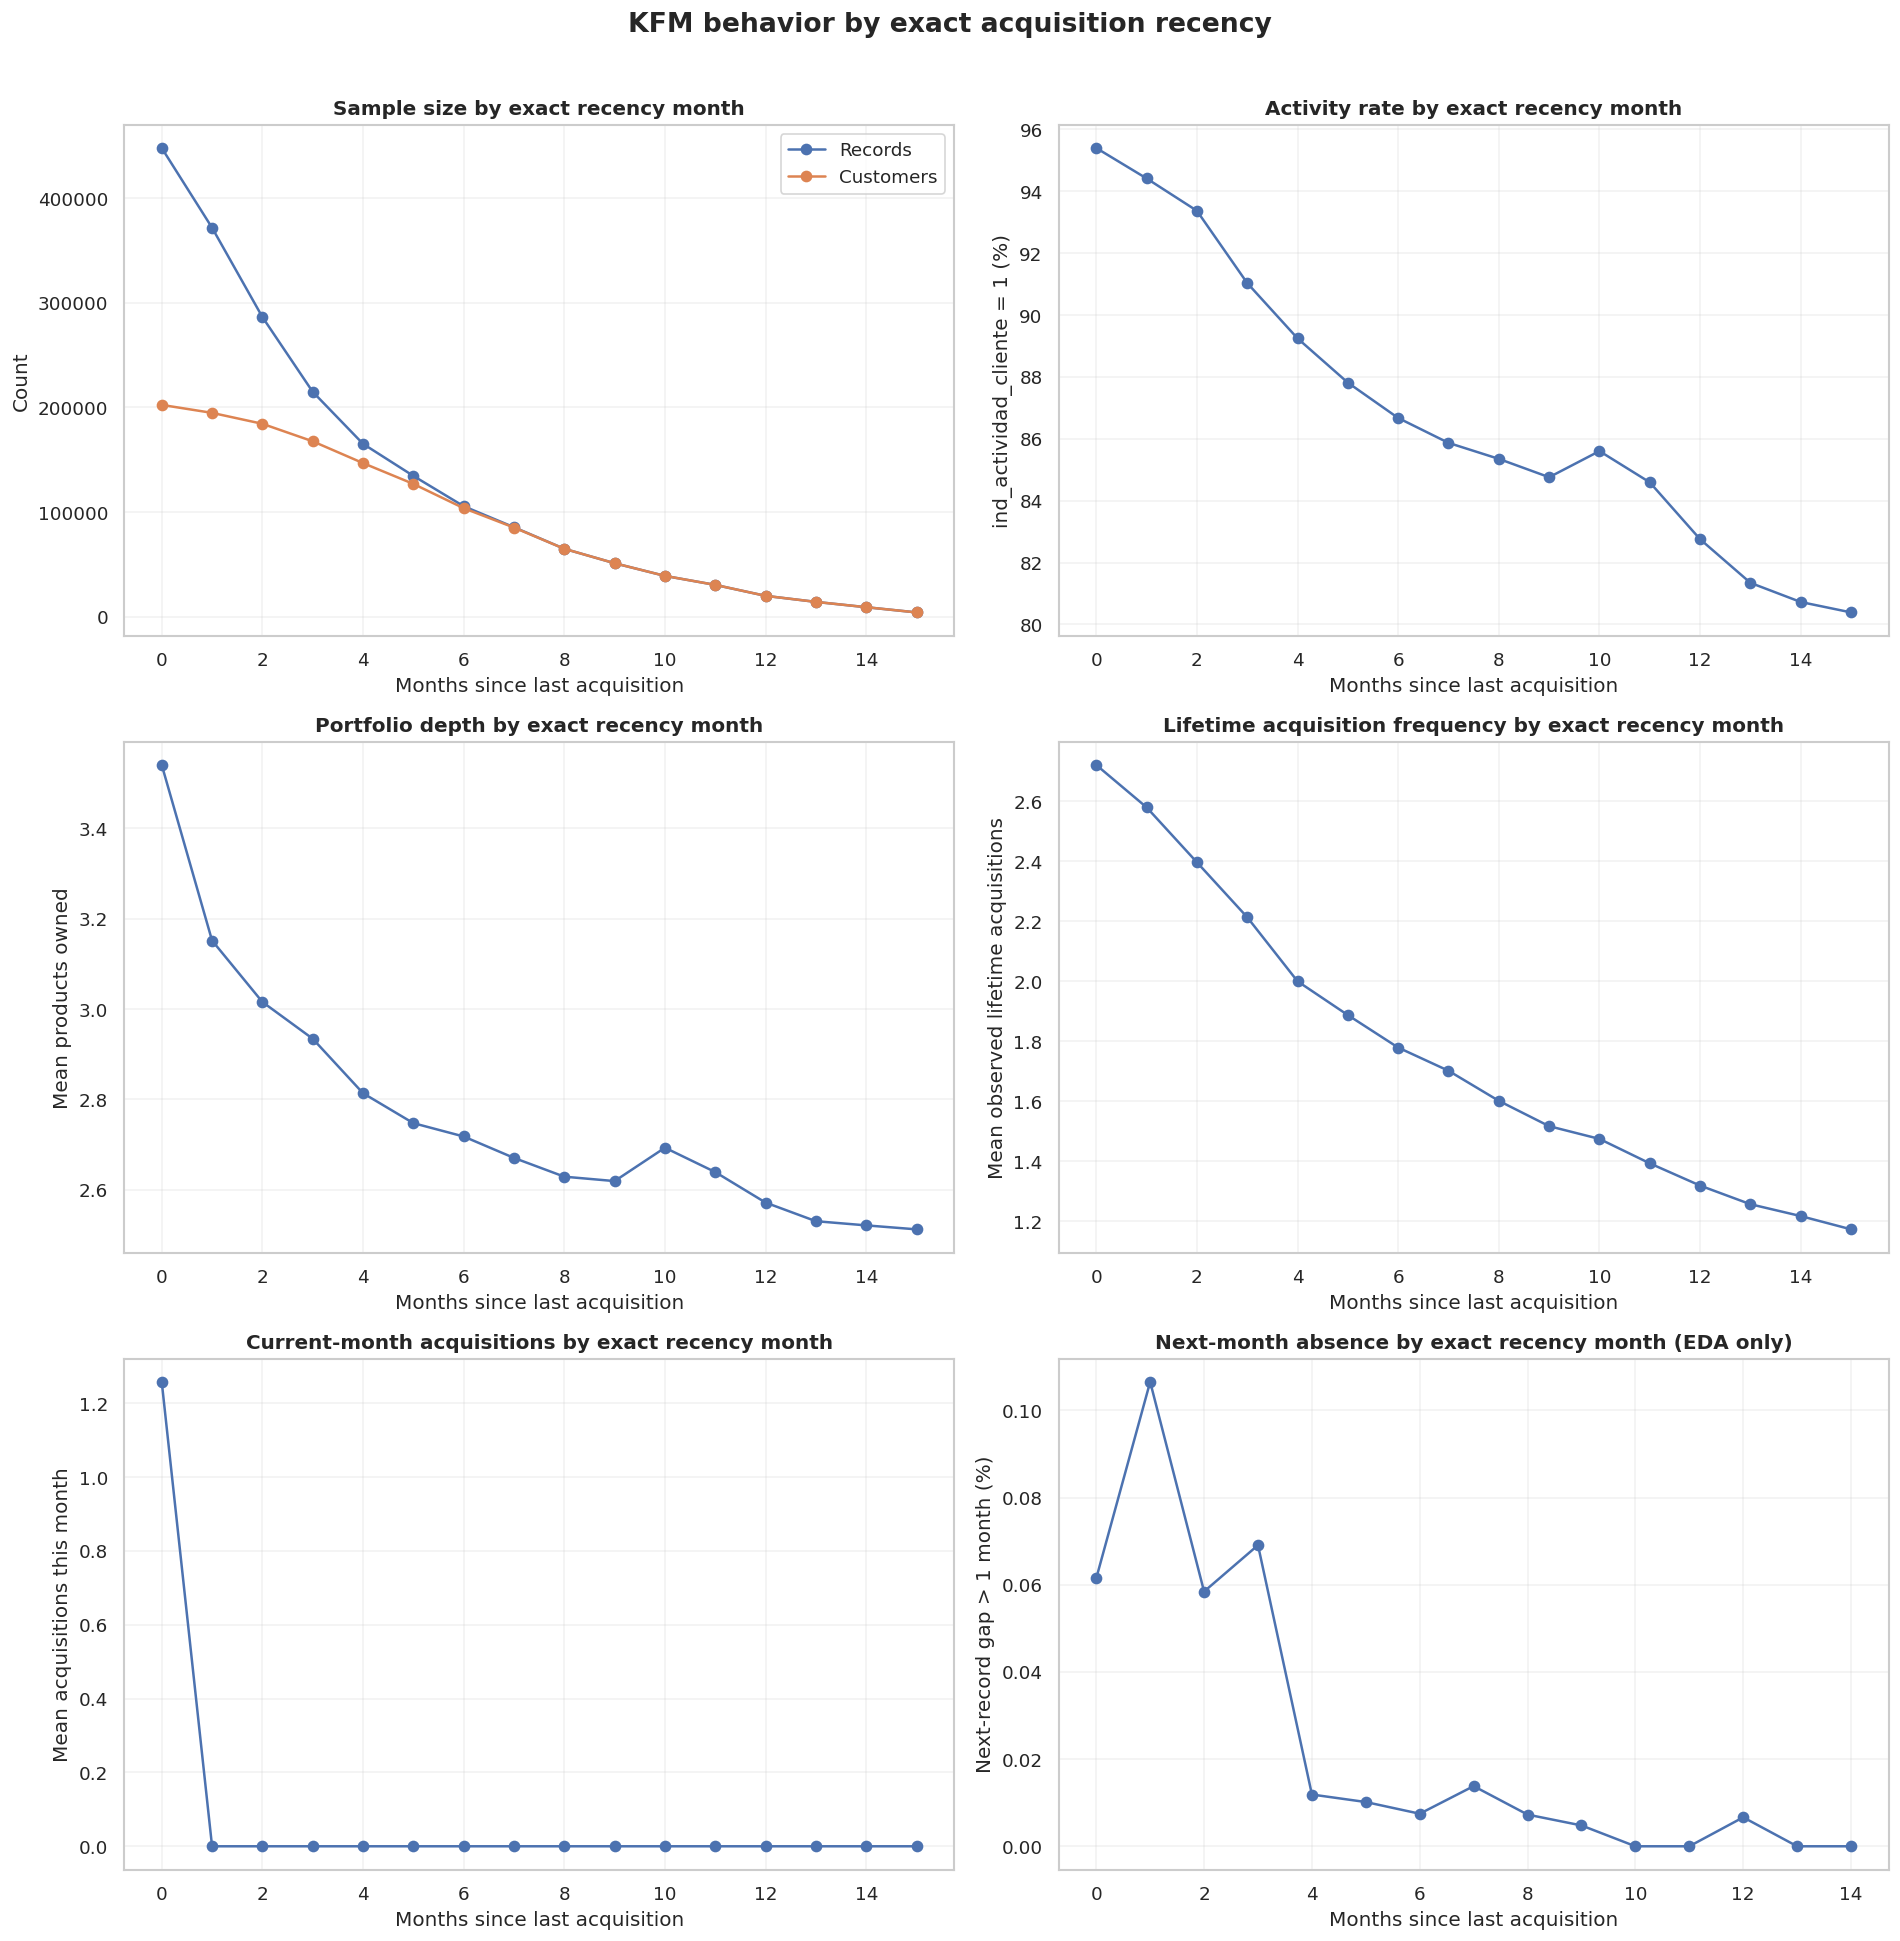

In [ ]:
# ## Visual EDA by exact KFM recency month

df = recency_month_evidence.copy().sort_values('recency_months')

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# ------------------------------------------------------------
# 1. Number of records / customers
# ------------------------------------------------------------
ax = axes[0, 0]

ax.plot(
    df['recency_months'],
    df['records'],
    marker='o',
    label='Records'
)

ax.plot(
    df['recency_months'],
    df['customers'],
    marker='o',
    label='Customers'
)

ax.set(
    title='Sample size by exact recency month',
    xlabel='Months since last acquisition',
    ylabel='Count'
)

ax.legend()
ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 2. Activity rate
# ------------------------------------------------------------
ax = axes[0, 1]

ax.plot(
    df['recency_months'],
    df['activity_rate'] * 100,
    marker='o'
)

ax.set(
    title='Activity rate by exact recency month',
    xlabel='Months since last acquisition',
    ylabel='ind_actividad_cliente = 1 (%)'
)

ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 3. Mean products currently owned (M)
# ------------------------------------------------------------
ax = axes[1, 0]

ax.plot(
    df['recency_months'],
    df['mean_products_owned'],
    marker='o'
)

ax.set(
    title='Portfolio depth by exact recency month',
    xlabel='Months since last acquisition',
    ylabel='Mean products owned'
)

ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 4. Mean lifetime acquisitions (F)
# ------------------------------------------------------------
ax = axes[1, 1]

ax.plot(
    df['recency_months'],
    df['mean_lifetime_acquisitions'],
    marker='o'
)

ax.set(
    title='Lifetime acquisition frequency by exact recency month',
    xlabel='Months since last acquisition',
    ylabel='Mean observed lifetime acquisitions'
)

ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 5. Mean acquisitions in current month
# ------------------------------------------------------------
ax = axes[2, 0]

ax.plot(
    df['recency_months'],
    df['mean_acquisitions_this_month'],
    marker='o'
)

ax.set(
    title='Current-month acquisitions by exact recency month',
    xlabel='Months since last acquisition',
    ylabel='Mean acquisitions this month'
)

ax.grid(alpha=0.25)


# ------------------------------------------------------------
# 6. Future record absence -- EDA ONLY
# ------------------------------------------------------------
ax = axes[2, 1]

ax.plot(
    df['recency_months'],
    df['next_month_absence_rate_eda_only'] * 100,
    marker='o'
)

ax.set(
    title='Next-month absence by exact recency month (EDA only)',
    xlabel='Months since last acquisition',
    ylabel='Next-record gap > 1 month (%)'
)

ax.grid(alpha=0.25)


fig.suptitle(
    'KFM behavior by exact acquisition recency',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,lifecycle_asof_eda,records,customers,mean_products_owned,mean_lifetime_acquisitions,activity_flag_rate
0,new,2836716,956645,1.30,0.06,42.46%
1,no_product_yet,8900506,830624,1.17,0.00,36.89%
2,active,973163,198552,3.35,2.76,95.20%
3,at_risk,514442,167801,2.85,2.06,89.59%
4,dormant,422482,103647,2.66,1.59,85.28%


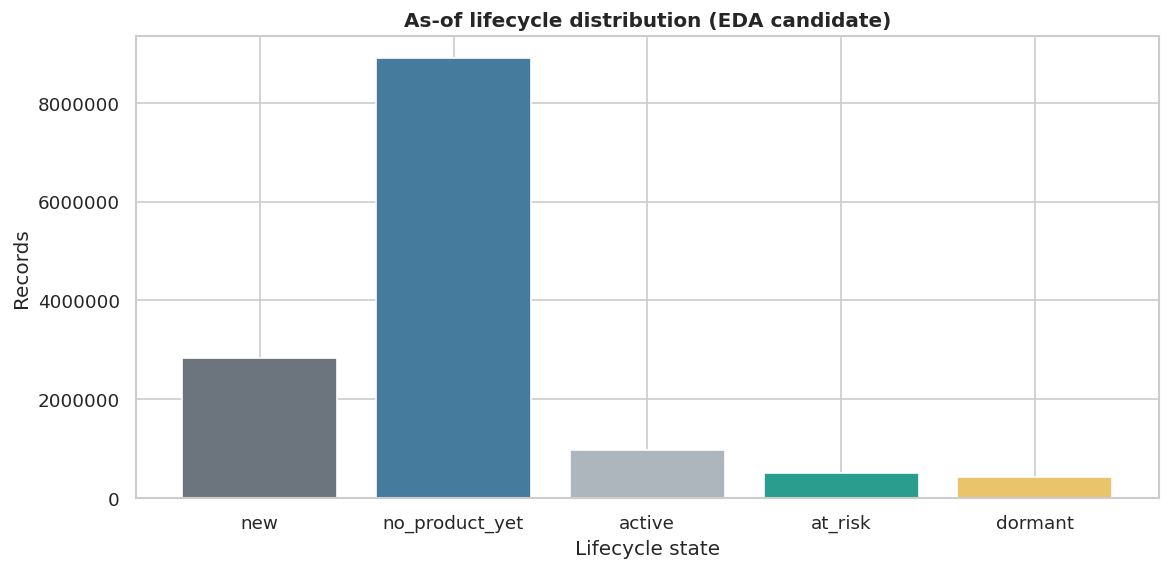

Raw KFM signals: /content/santander_eda/kfm_lifecycle_raw.parquet
Lifecycle candidate: /content/santander_eda/kfm_lifecycle_eda.parquet


In [ ]:
# ## 9.3 Create an as-of lifecycle feature from EDA-supported rules
# This lifecycle label is EDA-only. It uses no future row, so it is safe to inspect as a candidate model feature.
# 'churned' is intentionally absent: disappearing after this row is a future/censored outcome, not an as-of state.
LIFECYCLE_EDA_PATH = EDA_OUTPUT_DIR / 'kfm_lifecycle_eda.parquet'

con.execute(f'''
    COPY (
        SELECT
            *,
            CASE
                WHEN deceased_flag = 1 THEN 'deceased'
                WHEN customer_history_months <= 2 THEN 'new'
                WHEN kfm_recency_months IS NULL THEN 'no_product_yet'
                WHEN kfm_recency_months <= 2 THEN 'active'
                WHEN kfm_recency_months BETWEEN 3 AND 5 THEN 'at_risk'
                ELSE 'dormant'
            END AS lifecycle_asof_eda
        FROM read_parquet('{str(KFM_LIFECYCLE_PATH)}')
    ) TO '{str(LIFECYCLE_EDA_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)
''')

lifecycle_summary = con.execute('''
    SELECT
        lifecycle_asof_eda,
        COUNT(*)::BIGINT AS records,
        COUNT(DISTINCT ncodpers)::BIGINT AS customers,
        AVG(kfm_monetary_product_count) AS mean_products_owned,
        AVG(kfm_frequency_lifetime) AS mean_lifetime_acquisitions,
        AVG(COALESCE(activity_flag, 0)) AS activity_flag_rate
    FROM read_parquet(?)
    GROUP BY lifecycle_asof_eda
    ORDER BY CASE lifecycle_asof_eda
        WHEN 'deceased' THEN 0 WHEN 'new' THEN 1 WHEN 'no_product_yet' THEN 2
        WHEN 'active' THEN 3 WHEN 'at_risk' THEN 4 ELSE 5 END
''', [str(LIFECYCLE_EDA_PATH)]).fetchdf()

display(lifecycle_summary.style.format({
    'mean_products_owned': '{:.2f}', 'mean_lifetime_acquisitions': '{:.2f}', 'activity_flag_rate': '{:.2%}'
}))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(lifecycle_summary.lifecycle_asof_eda, lifecycle_summary.records, color=['#6c757d', '#457b9d', '#adb5bd', '#2a9d8f', '#e9c46a', '#e76f51'])
ax.set(title='As-of lifecycle distribution (EDA candidate)', xlabel='Lifecycle state', ylabel='Records')
ax.ticklabel_format(style='plain', axis='y')
plt.show()

print(f'Raw KFM signals: {KFM_LIFECYCLE_PATH}')
print(f'Lifecycle candidate: {LIFECYCLE_EDA_PATH}')


## 10. Kết luận EDA và hướng modelling

### Chất lượng panel

- Train panel có **13,647,309 record**, **956,645 customer**, trải từ **2015-01 đến 2016-05** (17 checkpoint). Mỗi checkpoint có đúng một record cho mỗi customer hiện diện.
- **63.3%** customer có đủ 17 checkpoint; phần còn lại có history ngắn hơn, nên không nên giả định panel cân bằng theo customer.
- **99.94%** transition record liên tiếp cách đúng **1 tháng**. Có thể dùng lag một checkpoint như lag tháng cho gần như toàn bộ data. Với gap > 1 tháng, giữ `record_gap_months` và cờ `is_continuous_gap`; không forward-fill product state qua gap nếu chưa kiểm chứng.

### Target acquisition và imbalance

- Với product `p`, chỉ train trên record có `prev_p = 0` và có previous observation. Label `1` là **0→1**, label `0` là **0→0**. Case **1→0** và **1→1** được in trong bảng EDA để hiểu vòng đời product, nhưng không thuộc population prediction acquisition từ 0.
- Imbalance rất mạnh và khác nhau theo product: `ind_cco_fin_ult1` có acquisition rate **1.6251%** (negative:positive ≈ **60.5:1**); `ind_ahor_fin_ult1` chỉ có **2 positive** (≈ **6.34 triệu:1**). Các product cực hiếm không đủ evidence để đánh giá binary model riêng một cách ổn định.
- Dùng **time-based split** theo checkpoint; không random split theo record. Đánh giá PR-AUC, recall@K/precision@K hoặc MAP@K thay vì accuracy/ROC-AUC đơn lẻ. Class weights hoặc negative downsampling chỉ fit trên train fold; validation/test giữ distribution gốc. Với product cực hiếm, cân nhắc rule/popularity baseline hoặc pooling/multi-task thay vì 24 model độc lập.

### Temporal / cyclic signal

- All-product acquisition rate dao động khoảng **0.15%–0.30%** theo checkpoint. Nhưng data chỉ có một năm đầy đủ + 5 tháng, nên đây là seasonality để thử nghiệm, **chưa đủ để kết luận chu kỳ năm bền vững**; cần kiểm chứng rolling temporal validation.
- Encode `fecha_dato`: `month` (1–12), `sin(2π·month/12)`, `cos(2π·month/12)`, `year`, `months_since_start`; dùng sin/cos để month 12 gần month 1. Có thể thử `quarter`/month-end checkpoint và chỉ giữ feature cải thiện validation.
- Với datetime profile như `fecha_alta`, không dùng raw datetime: tạo `customer_tenure_months = months_between(fecha_dato, fecha_alta)`, missing/invalid flag, tenure bins. Tất cả feature phải tính **as-of checkpoint hiện tại**.

### Hướng feature engineering / preprocessing

1. Product history leakage-safe: lag state `t-1`, số product đang sở hữu `t-1`, tổng acquisition/loss cửa sổ 1/3/6 tháng, time-since-last product change. Không dùng current-month `*_ult1` làm feature target tháng đó.
2. Numeric (`age`, `antiguedad`, `renta`): parse, clip, impute theo **train fold** và thêm missing indicator. Categorical: missing token; one-hot low-cardinality, frequency/OOF target encoding high-cardinality.
3. Continuity: thêm `record_gap_months`, `is_continuous_gap`, `customer_history_length`; reset hoặc kèm cờ gap cho lag/rolling feature sau gap.
4. Per temporal fold, fit imputation, clipping, encoders, class weights/downsampling bằng dữ liệu quá khứ. Calibration/threshold chọn trên validation checkpoint, không chọn trên test.


## 11. Product History EDA — specification-compliant extension

This section implements `docs/Product_features_EDA_spec.md`. It is deliberately independent from earlier exploratory cells: transitions require a one-month gap, product-state missingness is measured before any 0/1 interpretation, and every predictor used against a future outcome is calculated as of (t-1).

Run sections 11.1 → 11.5 in order after the bootstrap and input-validation cells. The generated artifacts remain on Colab's ephemeral disk.

In [19]:
# ## 11.1 Shared product-history dataset and validation
# Hypothesis
# ----------
# The 24 product columns can be used as binary states only after their missingness
# and temporal continuity have been audited.
#
# Objective
# ---------
# Build a reusable customer-month product-event/history artifact. A 0→1 or 1→0
# event exists only for a one-calendar-month transition with observed (non-null)
# states at both endpoints; no NULL is silently converted to 0.
#
# Logic
# -----
# - Input: train panel, sorted by ncodpers and fecha_dato.
# - Population: all observed customer-month records; first records and gaps are retained
#   for audit, but excluded from transition/event denominators.
# - Predictors later called "*_asof_prev" use rows ending at t-1 only.
# - Artifact is wide (24 products) to avoid materialising a 24× panel in pandas.
from pathlib import Path

EDA_OUTPUT_DIR = Path('/content/santander_eda')
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRODUCT_HISTORY_EDA_PATH = EDA_OUTPUT_DIR / 'product_history_eda.parquet'

def qi(name):
    return '"' + name.replace('"', '""') + '"'

product_state_sql = []
for p in PRODUCT_COLUMNS:
    product_state_sql += [
        f'TRY_CAST({qi(p)} AS INTEGER) AS cur_{p}',
        f'LAG(TRY_CAST({qi(p)} AS INTEGER)) OVER customer_time AS prev_{p}',
    ]

state_missing_current = ' + '.join(f'(cur_{p} IS NULL)::INTEGER' for p in PRODUCT_COLUMNS)
state_missing_previous = ' + '.join(f'(prev_{p} IS NULL)::INTEGER' for p in PRODUCT_COLUMNS)
owned_current = ' + '.join(f'cur_{p}' for p in PRODUCT_COLUMNS)
owned_previous = ' + '.join(f'prev_{p}' for p in PRODUCT_COLUMNS)

event_sql = []
acq_terms, drop_terms = [], []
for p in PRODUCT_COLUMNS:
    acq = (
        f"CASE WHEN record_gap_months = 1 AND prev_{p} = 0 AND cur_{p} = 1 THEN 1 "
        f"WHEN record_gap_months = 1 AND prev_{p} IS NOT NULL AND cur_{p} IS NOT NULL THEN 0 "
        f"ELSE NULL END"
    )
    drop = (
        f"CASE WHEN record_gap_months = 1 AND prev_{p} = 1 AND cur_{p} = 0 THEN 1 "
        f"WHEN record_gap_months = 1 AND prev_{p} IS NOT NULL AND cur_{p} IS NOT NULL THEN 0 "
        f"ELSE NULL END"
    )
    event_sql += [f'{acq} AS acq_{p}', f'{drop} AS drop_{p}']
    acq_terms.append(f'acq_{p}')
    drop_terms.append(f'drop_{p}')

con.execute(f"""
COPY (
    WITH raw_states AS (
        SELECT
            ncodpers,
            CAST(fecha_dato AS DATE) AS checkpoint_month,
            LAG(CAST(fecha_dato AS DATE)) OVER customer_time AS previous_month,
            {', '.join(product_state_sql)}
        FROM read_parquet('{str(TRAIN_PATH)}')
        WINDOW customer_time AS (PARTITION BY ncodpers ORDER BY fecha_dato)
    ),
    transitions AS (
        SELECT *,
            date_diff('month', previous_month, checkpoint_month)::INTEGER AS record_gap_months
        FROM raw_states
    ),
    events AS (
        SELECT *,
            {', '.join(event_sql)}
        FROM transitions
    ),
    history_base AS (
        SELECT *,
            MIN(checkpoint_month) OVER customer_time AS first_observed_month,
            CASE WHEN ({state_missing_current}) = 0 THEN ({owned_current}) ELSE NULL END
                AS products_owned_current,
            CASE WHEN ({state_missing_previous}) = 0 THEN ({owned_previous}) ELSE NULL END
                AS products_owned_previous,
            CASE WHEN record_gap_months = 1 AND ({state_missing_current}) = 0
                      AND ({state_missing_previous}) = 0
                 THEN ({' + '.join(acq_terms)}) ELSE NULL END AS acquisitions_current,
            CASE WHEN record_gap_months = 1 AND ({state_missing_current}) = 0
                      AND ({state_missing_previous}) = 0
                 THEN ({' + '.join(drop_terms)}) ELSE NULL END AS drops_current
        FROM events
        WINDOW customer_time AS (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        )
    )
    SELECT *,
        date_diff('month', first_observed_month, checkpoint_month)::INTEGER AS customer_history_months,
        SUM(COALESCE(acquisitions_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        )::INTEGER AS cumulative_acquisitions_asof_prev,
        MAX(CASE WHEN acquisitions_current > 0 THEN checkpoint_month END) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
        ) AS last_acquisition_month_asof_prev,
        SUM(COALESCE(acquisitions_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 1 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS acquisitions_last_1m_asof_prev,
        SUM(COALESCE(acquisitions_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 3 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS acquisitions_last_3m_asof_prev,
        SUM(COALESCE(acquisitions_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 6 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS acquisitions_last_6m_asof_prev,
        SUM(COALESCE(drops_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 1 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS drops_last_1m_asof_prev,
        SUM(COALESCE(drops_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 3 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS drops_last_3m_asof_prev,
        SUM(COALESCE(drops_current, 0)) OVER (
            PARTITION BY ncodpers ORDER BY checkpoint_month
            RANGE BETWEEN INTERVAL 6 MONTH PRECEDING AND INTERVAL 1 MONTH PRECEDING
        )::INTEGER AS drops_last_6m_asof_prev
    FROM history_base
) TO '{str(PRODUCT_HISTORY_EDA_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

missing_audit = con.execute(f"""
    SELECT
        COUNT(*)::BIGINT AS records,
        SUM(record_gap_months = 1)::BIGINT AS valid_gap_1_records,
        SUM(record_gap_months IS NOT NULL AND record_gap_months <> 1)::BIGINT AS excluded_gap_records,
        SUM(({state_missing_current}) > 0)::BIGINT AS records_with_current_product_missing,
        SUM(({state_missing_previous}) > 0)::BIGINT AS records_with_previous_product_missing,
        SUM(acquisitions_current IS NOT NULL)::BIGINT AS complete_state_valid_transitions,
        SUM(acquisitions_current)::BIGINT AS acquisition_events,
        SUM(drops_current)::BIGINT AS drop_events
    FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
""").fetchdf()
display(missing_audit)

assert missing_audit.loc[0, 'complete_state_valid_transitions'] <= missing_audit.loc[0, 'valid_gap_1_records']
print(f'Wrote reusable artifact: {PRODUCT_HISTORY_EDA_PATH}')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,records,valid_gap_1_records,excluded_gap_records,records_with_current_product_missing,records_with_previous_product_missing,complete_state_valid_transitions,acquisition_events,drop_events
0,13647309,12682421,8243,16063,966793,12669584,561648,529953


Wrote reusable artifact: /content/santander_eda/product_history_eda.parquet


### 11.2 Product state EDA (1.1–1.3)

**Hypothesis.** Product ownership is uneven over time, customer portfolios differ in depth, and state persistence is high for some products.

**Objective.** Measure product popularity, portfolio depth, and all four state transitions on valid consecutive observations.

**Logic.** State rates use only non-missing values for that product. Transition rates use only `record_gap_months = 1` and non-missing state pairs; they are descriptive, not acquisition-model labels.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,customer_count,observed_state_count,customers_holding,ownership_rate,net_holders_change
50,ind_cco_fin_ult1,931453,931453,561615,60.295%,-192.000000
407,ind_recibo_ult1,931453,931453,113050,12.137%,1302.000000
135,ind_ctop_fin_ult1,931453,931453,100589,10.799%,-451.000000
220,ind_ecue_fin_ult1,931453,931453,75845,8.143%,2114.000000
84,ind_cno_fin_ult1,931453,931453,73061,7.844%,1304.000000
390,ind_nom_pens_ult1,931453,931453,52848,5.674%,2176.000000
373,ind_nomina_ult1,931453,931453,48309,5.186%,2160.000000
305,ind_reca_fin_ult1,931453,931453,45535,4.889%,260.000000
322,ind_tjcr_fin_ult1,931453,931453,34822,3.738%,15.000000
152,ind_ctpp_fin_ult1,931453,931453,33271,3.572%,-203.000000


,product,transition_0_0,transition_0_1,transition_1_0,transition_1_1,prior_0_count,prior_1_count,p_state_1_given_prior_0,p_state_1_given_prior_1
17,ind_reca_fin_ult1,12003804,9234,11,669372,12013038,669383,0.0769%,99.998%
7,ind_ctop_fin_ult1,11018605,3869,9727,1650220,11022474,1659947,0.0351%,99.414%
15,ind_plan_fin_ult1,12564012,618,715,117076,12564630,117791,0.0049%,99.393%
14,ind_hip_fin_ult1,12606573,75,522,75251,12606648,75773,0.0006%,99.311%
20,ind_viv_fin_ult1,12632801,70,343,49207,12632871,49550,0.0006%,99.308%
16,ind_pres_fin_ult1,12648673,147,254,33347,12648820,33601,0.0012%,99.244%
0,ind_ahor_fin_ult1,12681101,2,12,1306,12681103,1318,0.0000%,99.090%
8,ind_ctpp_fin_ult1,12122286,2418,5339,552378,12124704,557717,0.0199%,99.043%
12,ind_ecue_fin_ult1,11602812,26361,11003,1042245,11629173,1053248,0.2267%,98.955%
2,ind_cco_fin_ult1,4230214,69103,89463,8293641,4299317,8383104,1.6073%,98.933%


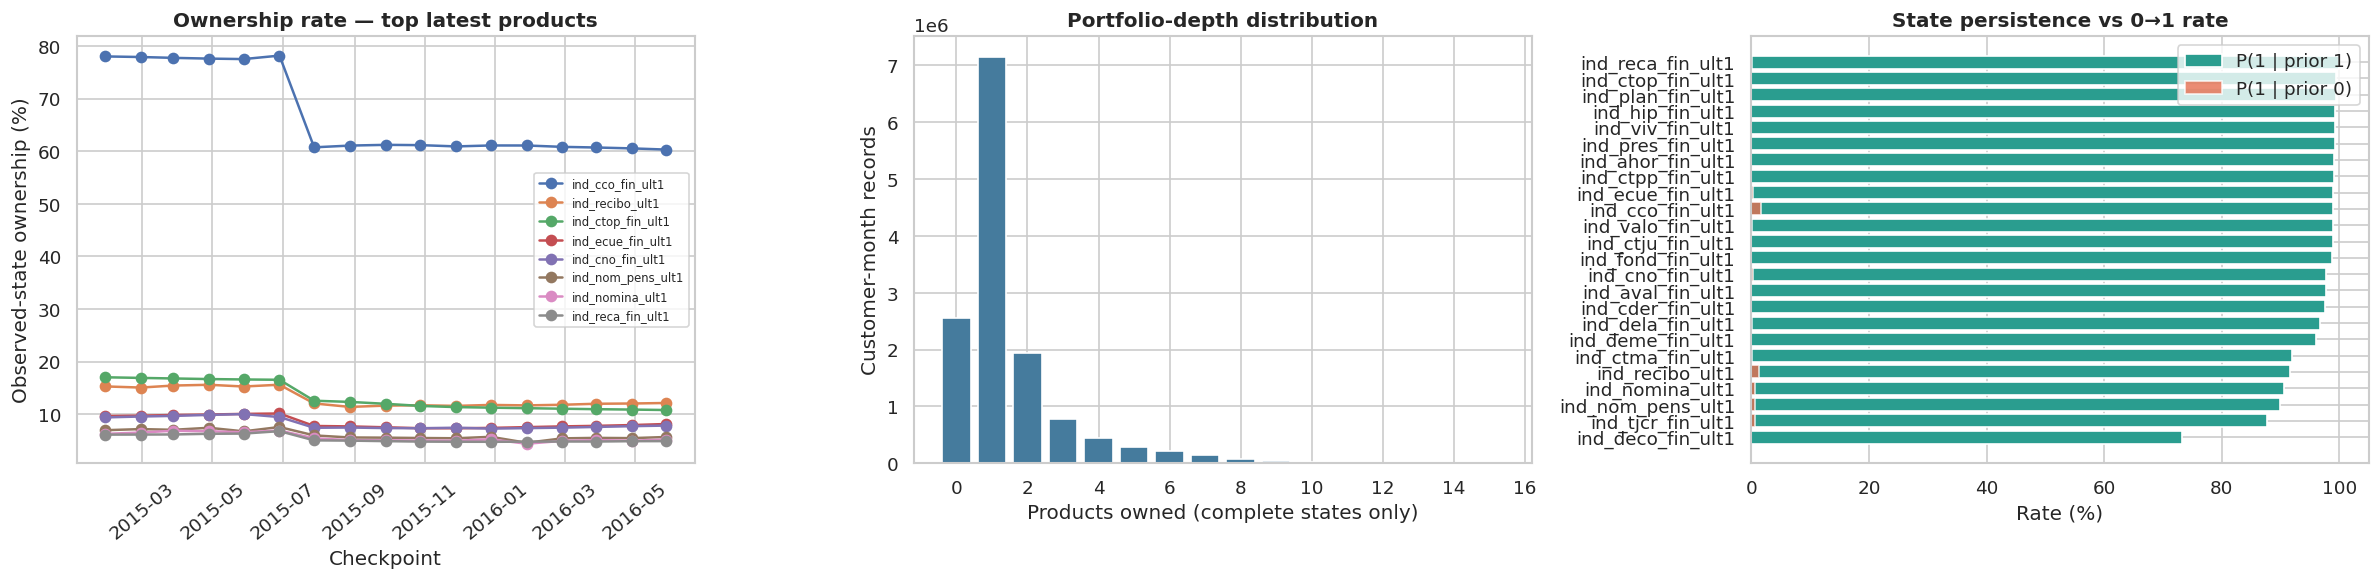

**Block 1 — Findings.** Latest observed ownership is highest for `ind_cco_fin_ult1` (60.29%; support 931,453 observed states). Median P(state_t=1 | state_t-1=1) across products is 98.80%. This supports investigating lagged product states and `products_owned_count`; validate incrementally with time-based folds.

In [38]:
# Result / visualization — EDA 1.1, 1.2, 1.3
ownership_sql = []
transition_sql = []
for p in PRODUCT_COLUMNS:
    ownership_sql.append(f"""
        SELECT checkpoint_month, '{p}' AS product,
               COUNT(*)::BIGINT AS customer_count,
               COUNT(cur_{p})::BIGINT AS observed_state_count,
               SUM(cur_{p} = 1)::BIGINT AS customers_holding,
               AVG(CASE WHEN cur_{p} = 1 THEN 1.0 WHEN cur_{p} = 0 THEN 0.0 ELSE NULL END) AS ownership_rate
        FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
        GROUP BY checkpoint_month
    """)
    transition_sql.append(f"""
        SELECT '{p}' AS product,
               COUNT(*) FILTER (WHERE prev_{p}=0 AND cur_{p}=0)::BIGINT AS transition_0_0,
               COUNT(*) FILTER (WHERE prev_{p}=0 AND cur_{p}=1)::BIGINT AS transition_0_1,
               COUNT(*) FILTER (WHERE prev_{p}=1 AND cur_{p}=0)::BIGINT AS transition_1_0,
               COUNT(*) FILTER (WHERE prev_{p}=1 AND cur_{p}=1)::BIGINT AS transition_1_1
        FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
        WHERE record_gap_months = 1 AND prev_{p} IS NOT NULL AND cur_{p} IS NOT NULL
    """)

ownership_by_month = con.execute(' UNION ALL '.join(ownership_sql)).fetchdf()
ownership_by_month['net_holders_change'] = ownership_by_month.sort_values('checkpoint_month').groupby('product')['customers_holding'].diff()
latest_ownership = ownership_by_month.sort_values('checkpoint_month').groupby('product', as_index=False).tail(1).sort_values('ownership_rate', ascending=False)

portfolio_depth = con.execute(f"""
    SELECT checkpoint_month, products_owned_current,
           COUNT(*)::BIGINT AS records,
           COUNT(DISTINCT ncodpers)::BIGINT AS customers
    FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
    WHERE products_owned_current IS NOT NULL
    GROUP BY checkpoint_month, products_owned_current
    ORDER BY checkpoint_month, products_owned_current
""").fetchdf()

transition_summary_113 = con.execute(' UNION ALL '.join(transition_sql)).fetchdf()
transition_summary_113['prior_0_count'] = transition_summary_113.transition_0_0 + transition_summary_113.transition_0_1
transition_summary_113['prior_1_count'] = transition_summary_113.transition_1_0 + transition_summary_113.transition_1_1
transition_summary_113['p_state_1_given_prior_0'] = transition_summary_113.transition_0_1 / transition_summary_113.prior_0_count.replace(0, np.nan)
transition_summary_113['p_state_1_given_prior_1'] = transition_summary_113.transition_1_1 / transition_summary_113.prior_1_count.replace(0, np.nan)

display(latest_ownership[['product','customer_count','observed_state_count','customers_holding','ownership_rate','net_holders_change']].style.format({'ownership_rate':'{:.3%}'}))
display(transition_summary_113.sort_values('p_state_1_given_prior_1', ascending=False).style.format({
    'p_state_1_given_prior_0':'{:.4%}', 'p_state_1_given_prior_1':'{:.3%}'
}))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
top_state_products = latest_ownership.head(8)['product'].tolist()
for p in top_state_products:
    x = ownership_by_month[ownership_by_month['product'].eq(p)].sort_values('checkpoint_month')
    axes[0].plot(x.checkpoint_month, x.ownership_rate * 100, marker='o', label=p)
axes[0].set(title='Ownership rate — top latest products', ylabel='Observed-state ownership (%)', xlabel='Checkpoint')
axes[0].tick_params(axis='x', rotation=40); axes[0].legend(fontsize=7)

depth_summary = portfolio_depth.groupby('products_owned_current', as_index=False).records.sum()
axes[1].bar(depth_summary.products_owned_current, depth_summary.records, color='#457b9d')
axes[1].set(title='Portfolio-depth distribution', xlabel='Products owned (complete states only)', ylabel='Customer-month records')
plot_transition = transition_summary_113.sort_values('p_state_1_given_prior_1')
axes[2].barh(plot_transition['product'], plot_transition.p_state_1_given_prior_1 * 100, label='P(1 | prior 1)', color='#2a9d8f')
axes[2].barh(plot_transition['product'], plot_transition.p_state_1_given_prior_0 * 100, label='P(1 | prior 0)', color='#e76f51', alpha=.8)
axes[2].set(title='State persistence vs 0→1 rate', xlabel='Rate (%)'); axes[2].legend()
plt.tight_layout(); plt.show()

# Insight / impact generated after output, not pre-written.
top_latest = latest_ownership.iloc[0]
median_persistence = transition_summary_113.p_state_1_given_prior_1.median()
display(Markdown(
    f"**Block 1 — Findings.** Latest observed ownership is highest for "
    f"`{top_latest['product']}` ({top_latest.ownership_rate:.2%}; support "
    f"{top_latest.observed_state_count:,} observed states). Median P(state_t=1 | state_t-1=1) "
    f"across products is {median_persistence:.2%}. This supports investigating lagged product states "
    f"and `products_owned_count`; validate incrementally with time-based folds."
))

Ở checkpoint cuối, ind_cco_fin_ult1 là product phổ biến nhất: 561,615/931,453 khách hàng sở hữu,
    tương đương 60.295%.

  - Nhóm product sau đó giảm rất mạnh: ind_recibo_ult1 12.137%, ind_ctop_fin_ult1 10.799%,
    ind_ecue_fin_ult1 8.143%. Nhiều product cực hiếm; ind_aval_fin_ult1 chỉ 16 holders (0.002%). Vì vậy
    cần xử lý theo product, không dùng một giả định imbalance chung cho cả 24 product.

  - Persistence rất cao: median (P(state_t=1 \mid state_{t-1}=1)) là 98.799% trên 24 product.
    ind_reca_fin_ult1 gần như không đổi trạng thái (99.998%, support 669,383 prior owners).

  - Product có persistence thấp nhất vẫn là ind_deco_fin_ult1 với 73.285%; đây là nhóm đáng điều tra
  - Với population prior non-owner, acquisition cao nhất là ind_cco_fin_ult1 ở 1.607%. Nghĩa là ngay cả
    product “dễ acquire” nhất vẫn có positive class hiếm.

  association từ EDA và cần temporal validation trước khi chốt feature.

### 11.3 Product event EDA (2.1–2.4)

**Hypothesis.** Acquisition is rare and product-specific; its rate changes by checkpoint, and some customer-months contain multiple acquisitions.

**Objective.** Reuse the validated event artifact to quantify acquisition/drop support, imbalance, timing, and multi-product events.

**Logic.** `eligible` means a complete, consecutive transition with prior state 0. Rates always show their denominators; acquisition and drop are never inferred across gaps.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product,eligible,acquisitions,negatives,drop_eligible,drops,acquisition_rate,negative_to_positive_ratio
2,ind_cco_fin_ult1,4299317,69103,4230214,8383104,89463,1.6073%,61.2:1
20,ind_recibo_ult1,11050679,153146,10897533,1631742,136273,1.3859%,71.2:1
15,ind_nom_pens_ult1,11912562,84709,11827853,757022,76035,0.7111%,139.6:1
16,ind_nomina_ult1,11972124,73753,11898371,697460,65260,0.6160%,161.3:1
21,ind_tjcr_fin_ult1,12111689,69118,12042571,570732,70340,0.5707%,174.2:1
4,ind_cno_fin_ult1,11651926,37098,11614828,1030495,23837,0.3184%,313.1:1
12,ind_ecue_fin_ult1,11629173,26361,11602812,1053248,11003,0.2267%,440.2:1
10,ind_dela_fin_ult1,12127261,12659,12114602,555160,18515,0.1044%,957.0:1
19,ind_reca_fin_ult1,12013038,9234,12003804,669383,11,0.0769%,"1,300.0:1"
6,ind_ctma_fin_ult1,12557789,6856,12550933,124632,10018,0.0546%,"1,830.6:1"


,acquisitions_current,records,customers
0,0,12223132,941338
1,1,355627,183567
2,2,68933,44631
3,3,19561,18239
4,4,2191,2177
5,5,133,133
6,6,6,6
7,7,1,1


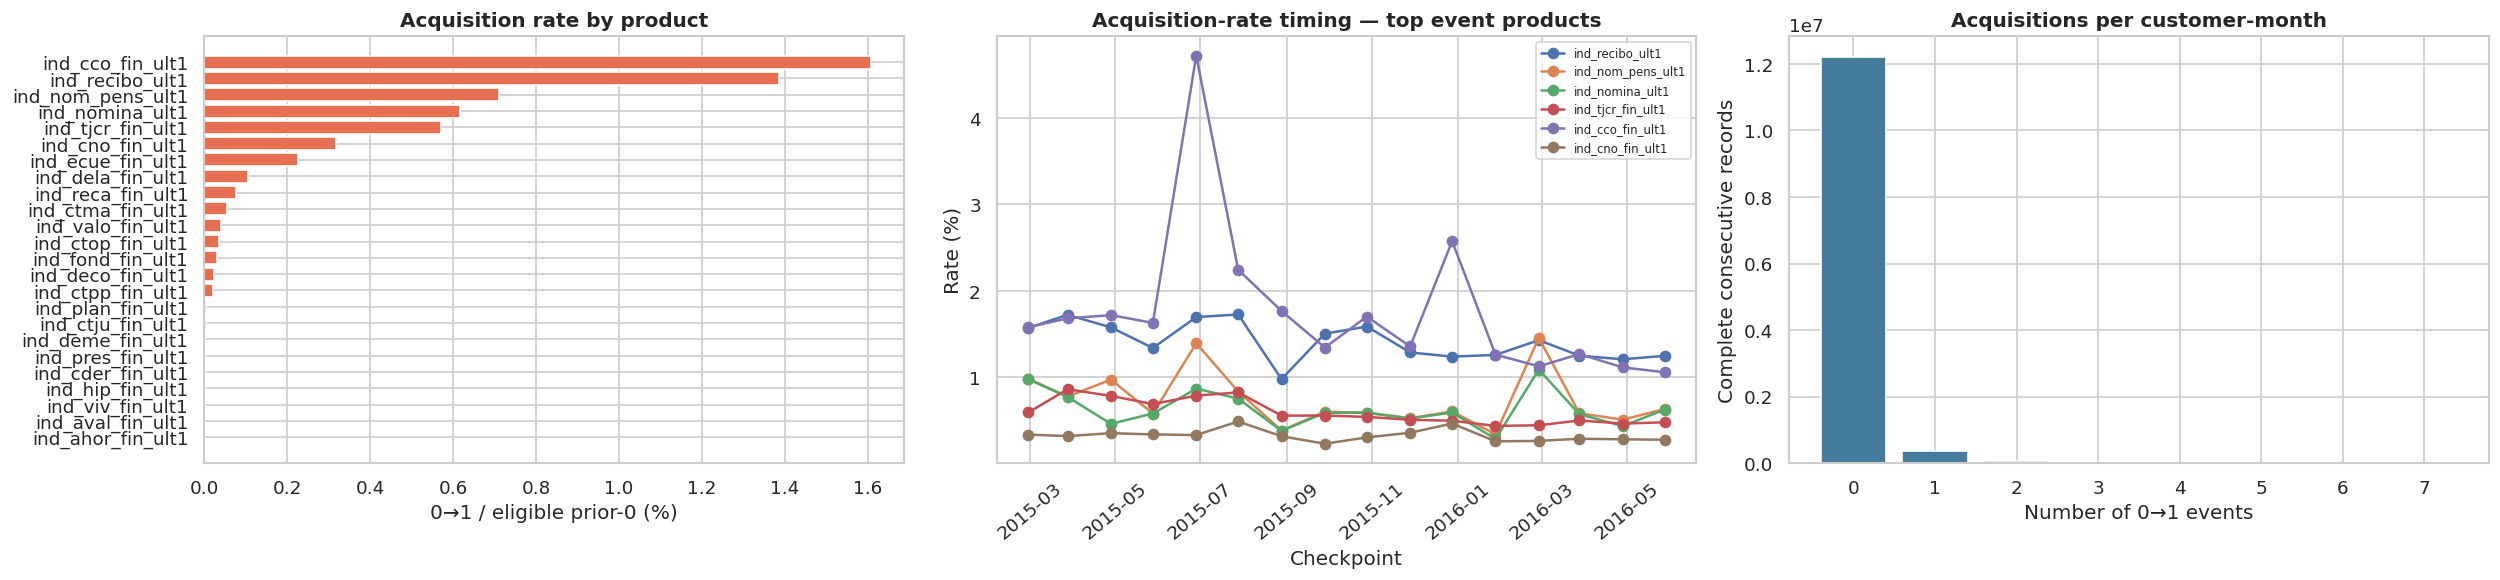

**Block 2 — Findings.** The highest observed product-level 0→1 rate is `ind_cco_fin_ult1` at 1.6073% over 4,299,317 eligible opportunities. Customer-months with more than one acquisition account for 0.72% of complete transitions. Use product-specific imbalance handling; multi-acquisition support motivates the pair analysis below.

In [39]:
# Result / visualization — EDA 2.1, 2.2, 2.3, 2.4
event_product_sql = []
for p in PRODUCT_COLUMNS:
    event_product_sql.append(f"""
        SELECT checkpoint_month, '{p}' AS product,
            COUNT(*) FILTER (WHERE record_gap_months=1 AND prev_{p}=0 AND cur_{p} IS NOT NULL)::BIGINT AS eligible,
            COUNT(*) FILTER (WHERE record_gap_months=1 AND prev_{p}=0 AND cur_{p}=1)::BIGINT AS acquisitions,
            COUNT(*) FILTER (WHERE record_gap_months=1 AND prev_{p}=0 AND cur_{p}=0)::BIGINT AS negatives,
            COUNT(*) FILTER (WHERE record_gap_months=1 AND prev_{p}=1 AND cur_{p} IS NOT NULL)::BIGINT AS drop_eligible,
            COUNT(*) FILTER (WHERE record_gap_months=1 AND prev_{p}=1 AND cur_{p}=0)::BIGINT AS drops
        FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
        GROUP BY checkpoint_month
    """)
event_by_month_product = con.execute(' UNION ALL '.join(event_product_sql)).fetchdf()
event_by_month_product['acquisition_rate'] = event_by_month_product.acquisitions / event_by_month_product.eligible.replace(0, np.nan)
event_by_month_product['drop_rate'] = event_by_month_product.drops / event_by_month_product.drop_eligible.replace(0, np.nan)

imbalance_by_product = event_by_month_product.groupby('product', as_index=False)[['eligible','acquisitions','negatives','drop_eligible','drops']].sum()
imbalance_by_product['acquisition_rate'] = imbalance_by_product.acquisitions / imbalance_by_product.eligible.replace(0, np.nan)
imbalance_by_product['negative_to_positive_ratio'] = imbalance_by_product.negatives / imbalance_by_product.acquisitions.replace(0, np.nan)
imbalance_by_product = imbalance_by_product.sort_values('acquisition_rate', ascending=False)
display(imbalance_by_product.style.format({'acquisition_rate':'{:.4%}', 'negative_to_positive_ratio':'{:,.1f}:1'}))

acquisitions_per_customer_month = con.execute(f"""
    SELECT acquisitions_current, COUNT(*)::BIGINT AS records, COUNT(DISTINCT ncodpers)::BIGINT AS customers
    FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
    WHERE acquisitions_current IS NOT NULL
    GROUP BY acquisitions_current ORDER BY acquisitions_current
""").fetchdf()
display(acquisitions_per_customer_month)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
ranked = imbalance_by_product.sort_values('acquisition_rate')
axes[0].barh(ranked['product'], ranked['acquisition_rate'] * 100, color='#e76f51')
axes[0].set(title='Acquisition rate by product', xlabel='0→1 / eligible prior-0 (%)')
top_events = event_by_month_product.groupby('product').acquisitions.sum().nlargest(6).index
for p in top_events:
    x = event_by_month_product[event_by_month_product['product'].eq(p)].sort_values('checkpoint_month')
    axes[1].plot(x['checkpoint_month'], x['acquisition_rate'] * 100, marker='o', label=p)
axes[1].set(title='Acquisition-rate timing — top event products', ylabel='Rate (%)', xlabel='Checkpoint')
axes[1].tick_params(axis='x', rotation=40); axes[1].legend(fontsize=7)
axes[2].bar(acquisitions_per_customer_month['acquisitions_current'], acquisitions_per_customer_month['records'], color='#457b9d')
axes[2].set(title='Acquisitions per customer-month', xlabel='Number of 0→1 events', ylabel='Complete consecutive records')
plt.tight_layout(); plt.show()

multi_rate = acquisitions_per_customer_month.loc[acquisitions_per_customer_month['acquisitions_current'].gt(1), 'records'].sum() / acquisitions_per_customer_month['records'].sum()
display(Markdown(
    f"**Block 2 — Findings.** The highest observed product-level 0→1 rate is "
    f"`{imbalance_by_product.iloc[0]['product']}` at {imbalance_by_product.iloc[0]['acquisition_rate']:.4%} "
    f"over {imbalance_by_product.iloc[0]['eligible']:,} eligible opportunities. "
    f"Customer-months with more than one acquisition account for {multi_rate:.2%} of complete transitions. "
    f"Use product-specific imbalance handling; multi-acquisition support motivates the pair analysis below."
))

### 11.4 Historical behavior EDA (3.1–3.7)

**Hypothesis.** Recency, cumulative/recent acquisitions, recent drops, portfolio depth, and history availability are associated with next-month acquisition.

**Objective.** Test leakage-safe predictors measured as of (t-1) against `any_acquisition_t`, then inspect redundancy.

**Logic.** The outcome is current `acquisitions_current > 0` on complete consecutive transitions. All predictors explicitly end before the current checkpoint. Missing recency means “no prior observed acquisition” and remains a separate group.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,feature_value,records,customers,future_acquisition_count,future_acquisition_rate,feature_name
0,1,418000,195164,47524,11.369%,recency
1,2,345871,186667,60580,17.515%,recency
2,3,264149,175132,50314,19.048%,recency
3,4,191698,156493,27454,14.321%,recency
4,5,150989,136518,17297,11.456%,recency
5,6,117738,113453,12738,10.819%,recency
6,7,93297,92209,8352,8.952%,recency
7,8,72033,72033,7659,10.633%,recency
8,9,54651,54651,4057,7.423%,recency
9,10,41478,41478,2960,7.136%,recency


,feature_value,records,customers,future_acquisition_count,future_acquisition_rate,feature_name
0,never_acquired_before_t,10837334,943287,201761,1.862%,recency


,feature_value,records,customers,future_acquisition_count,future_acquisition_rate,feature_name
0,0,2291853,265344,34365,1.499%,products_owned_previous
1,1,6700378,529503,141235,2.108%,products_owned_previous
2,2,1809204,186608,87746,4.850%,products_owned_previous
3,3,722756,96398,66699,9.228%,products_owned_previous
4,4,421213,64281,45919,10.902%,products_owned_previous
5,5,271830,41667,31731,11.673%,products_owned_previous
6,6,198252,28813,20239,10.209%,products_owned_previous
7,7,133127,18403,10963,8.235%,products_owned_previous
8,8,71694,9857,4948,6.902%,products_owned_previous
9,9,31871,4433,1805,5.663%,products_owned_previous


,feature_value,records,customers,future_acquisition_count,future_acquisition_rate,feature_name
0,0,12251584,943287,398928,3.256%,acquisitions_last_1m_asof_prev
1,1,333536,177026,32857,9.851%,acquisitions_last_1m_asof_prev
2,2,64073,42593,11492,17.936%,acquisitions_last_1m_asof_prev
3,3,18213,17065,2887,15.851%,acquisitions_last_1m_asof_prev
4,4,2050,2039,266,12.976%,acquisitions_last_1m_asof_prev
5,5,122,122,21,17.213%,acquisitions_last_1m_asof_prev
6,6,5,5,1,20.000%,acquisitions_last_1m_asof_prev
7,7,1,1,0,0.000%,acquisitions_last_1m_asof_prev
8,0,11641564,943287,288034,2.474%,acquisitions_last_3m_asof_prev
9,1,722279,174889,103114,14.276%,acquisitions_last_3m_asof_prev


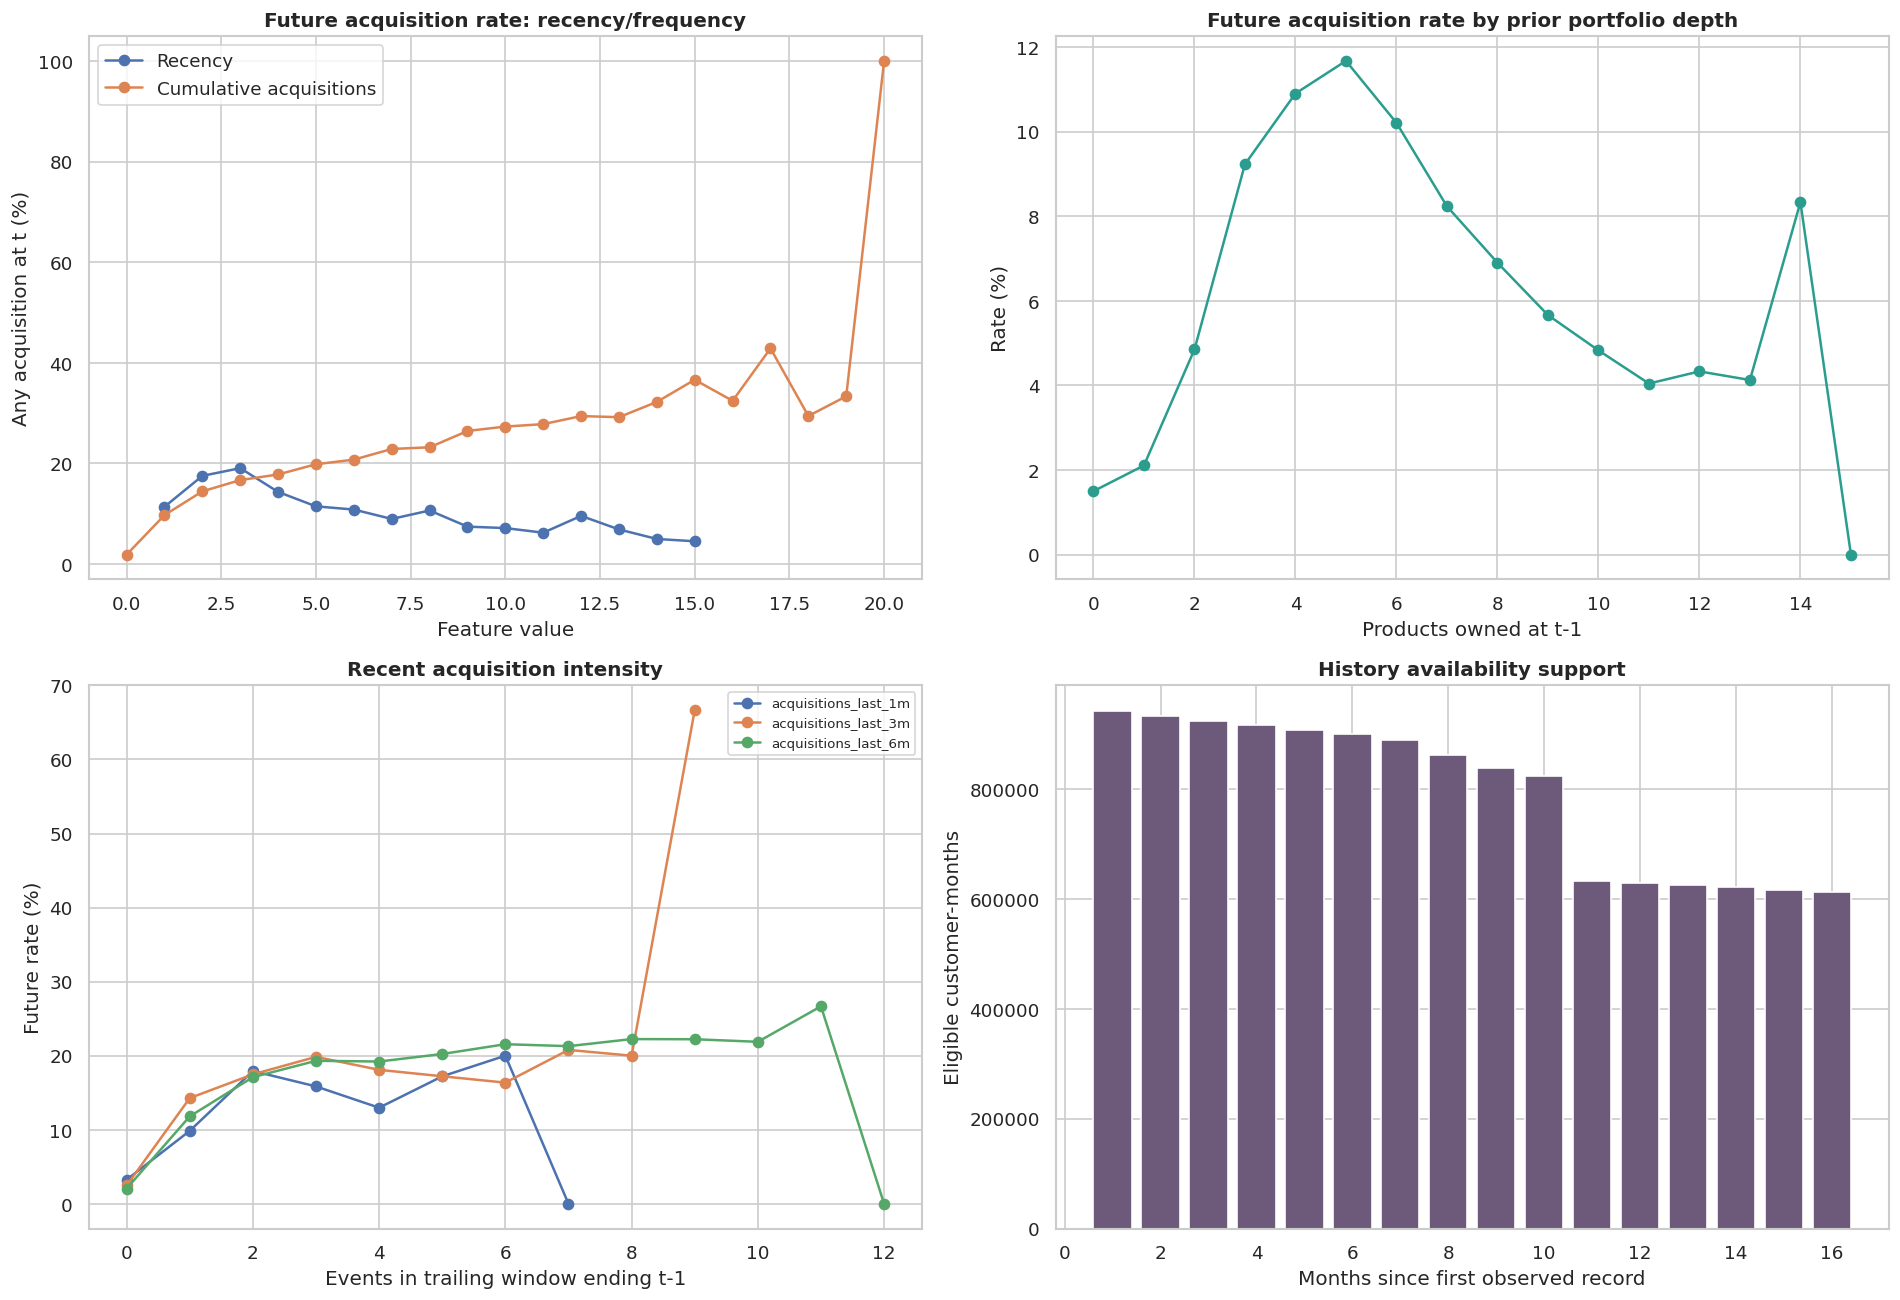

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Spearman-style rank correlation
corr_0_1,0.391127
corr_0_2,0.714694
corr_0_3,0.320249
corr_0_4,-0.231994
corr_1_2,0.650310
corr_1_3,0.223015
corr_1_4,-0.804543
corr_2_3,0.279244
corr_2_4,-0.529186
corr_3_4,-0.160180


**Block 3 — Findings.** Among non-null recency groups, the highest observed future-acquisition rate is 19.048% at recency=3 (support 264,149). Interpret sparse tails with caution. Candidate features remain months_since_last_acquisition, cumulative/recent acquisition counts, prior portfolio depth, and history length; use the rank-correlation table plus temporal validation to decide which redundant windows to retain.

In [28]:
# Result / visualization — EDA 3.1–3.7
con.execute(f"""
CREATE OR REPLACE TEMP VIEW product_history_future AS
SELECT *,
    date_diff('month', last_acquisition_month_asof_prev, checkpoint_month)::INTEGER
        AS months_since_last_acquisition_asof_prev,
    (acquisitions_current > 0)::INTEGER AS any_acquisition_t
FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
WHERE acquisitions_current IS NOT NULL
""")

def future_rate_by(feature, label=None, where='TRUE'):
    return con.execute(f"""
        SELECT {feature} AS feature_value,
               COUNT(*)::BIGINT AS records,
               COUNT(DISTINCT ncodpers)::BIGINT AS customers,
               SUM(any_acquisition_t)::BIGINT AS future_acquisition_count,
               AVG(any_acquisition_t) AS future_acquisition_rate
        FROM product_history_future
        WHERE {where}
        GROUP BY {feature}
        ORDER BY feature_value
    """).fetchdf().assign(feature_name=label or feature)

recency_future = future_rate_by('months_since_last_acquisition_asof_prev', 'recency', 'months_since_last_acquisition_asof_prev IS NOT NULL')
never_acquired_future = future_rate_by("'never_acquired_before_t'", 'recency', 'months_since_last_acquisition_asof_prev IS NULL')
frequency_future = future_rate_by('cumulative_acquisitions_asof_prev', 'cumulative_acquisitions')
portfolio_future = future_rate_by('products_owned_previous', 'products_owned_previous', 'products_owned_previous IS NOT NULL')
history_availability = future_rate_by('customer_history_months', 'customer_history_months')

intensity_frames = []
for feature in [
    'acquisitions_last_1m_asof_prev', 'acquisitions_last_3m_asof_prev', 'acquisitions_last_6m_asof_prev',
    'drops_last_1m_asof_prev', 'drops_last_3m_asof_prev', 'drops_last_6m_asof_prev',
]:
    intensity_frames.append(future_rate_by(feature))
intensity_future = pd.concat(intensity_frames, ignore_index=True)

display(recency_future.style.format({'future_acquisition_rate':'{:.3%}'}))
display(never_acquired_future.style.format({'future_acquisition_rate':'{:.3%}'}))
display(portfolio_future.style.format({'future_acquisition_rate':'{:.3%}'}))
display(intensity_future.style.format({'future_acquisition_rate':'{:.3%}'}))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for data, name in [(recency_future, 'Recency'), (frequency_future, 'Cumulative acquisitions')]:
    axes[0, 0].plot(data.feature_value, data.future_acquisition_rate * 100, marker='o', label=name)
axes[0, 0].set(title='Future acquisition rate: recency/frequency', xlabel='Feature value', ylabel='Any acquisition at t (%)')
axes[0, 0].legend()
axes[0, 1].plot(portfolio_future.feature_value, portfolio_future.future_acquisition_rate * 100, marker='o', color='#2a9d8f')
axes[0, 1].set(title='Future acquisition rate by prior portfolio depth', xlabel='Products owned at t-1', ylabel='Rate (%)')
for feature, group in intensity_future[intensity_future.feature_name.str.startswith('acquisitions')].groupby('feature_name'):
    axes[1, 0].plot(group.feature_value, group.future_acquisition_rate * 100, marker='o', label=feature.replace('_asof_prev',''))
axes[1, 0].set(title='Recent acquisition intensity', xlabel='Events in trailing window ending t-1', ylabel='Future rate (%)'); axes[1, 0].legend(fontsize=8)
axes[1, 1].bar(history_availability.feature_value, history_availability.records, color='#6d597a')
axes[1, 1].set(title='History availability support', xlabel='Months since first observed record', ylabel='Eligible customer-months')
plt.tight_layout(); plt.show()

# Spearman-style ranks are calculated inside DuckDB; only the small correlation matrix is returned.
redundancy_features = [
    'cumulative_acquisitions_asof_prev', 'acquisitions_last_3m_asof_prev',
    'acquisitions_last_6m_asof_prev', 'products_owned_previous',
    'months_since_last_acquisition_asof_prev'
]
rank_sql = ', '.join(
    f'percent_rank() OVER (ORDER BY {x}) AS r_{i}' for i, x in enumerate(redundancy_features)
)
corr_sql = ', '.join(
    f'corr(r_{i}, r_{j}) AS corr_{i}_{j}'
    for i in range(len(redundancy_features)) for j in range(i + 1, len(redundancy_features))
)
rank_corr = con.execute(f"""
    WITH ranked AS (
        SELECT {rank_sql}
        FROM product_history_future
        WHERE products_owned_previous IS NOT NULL
          AND months_since_last_acquisition_asof_prev IS NOT NULL
    )
    SELECT {corr_sql} FROM ranked
""").fetchdf()
display(rank_corr.T.rename(columns={0:'Spearman-style rank correlation'}))

peak_recency = recency_future.loc[recency_future.future_acquisition_rate.idxmax()]
display(Markdown(
    f"**Block 3 — Findings.** Among non-null recency groups, the highest observed future-acquisition "
    f"rate is {peak_recency.future_acquisition_rate:.3%} at recency={int(peak_recency.feature_value)} "
    f"(support {peak_recency.records:,}). Interpret sparse tails with caution. Candidate features remain "
    f"months_since_last_acquisition, cumulative/recent acquisition counts, prior portfolio depth, and "
    f"history length; use the rank-correlation table plus temporal validation to decide which redundant windows to retain."
))

### 11.5 Product-relationship EDA (4.1–4.5) and candidate registry

**Hypothesis.** Co-ownership and acquisitions may exhibit product-pair structure beyond product popularity alone.

**Objective.** Measure ownership lift, same-month co-acquisition, and calendar-month sequential lift through six months.

**Logic.** Pair probabilities include support. Sequential joins use exact `date_diff(month)=k` calendar offsets—not the next observed row—and compare (P(B_{t+k}|A_t)) with the marginal (P(B_{t+k})).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_a,product_b,both_count,a_count,b_count,p_b_given_a,p_a_given_b,lift
0,ind_deco_fin_ult1,ind_deme_fin_ult1,1215,24275.000000,22668.000000,5.005%,5.360%,30.13
1,ind_ahor_fin_ult1,ind_viv_fin_ult1,128,1396.000000,52511.000000,9.169%,0.244%,23.83
2,ind_aval_fin_ult1,ind_valo_fin_ult1,145,316.000000,349475.000000,45.886%,0.041%,17.92
3,ind_nom_pens_ult1,ind_nomina_ult1,745961,810085.000000,745961.000000,92.084%,100.000%,16.85
4,ind_cno_fin_ult1,ind_nomina_ult1,701346,1103620.000000,745961.000000,63.550%,94.019%,11.63
5,ind_cno_fin_ult1,ind_nom_pens_ult1,760134,1103620.000000,810085.000000,68.876%,93.834%,11.60
6,ind_cder_fin_ult1,ind_valo_fin_ult1,1563,5376.000000,349475.000000,29.074%,0.447%,11.35
7,ind_aval_fin_ult1,ind_nomina_ult1,192,316.000000,745961.000000,60.759%,0.026%,11.12
8,ind_aval_fin_ult1,ind_tjcr_fin_ult1,155,316.000000,605786.000000,49.051%,0.026%,11.05
9,ind_aval_fin_ult1,ind_reca_fin_ult1,178,316.000000,716980.000000,56.329%,0.025%,10.72


,product_a,product_b,both_count,a_count,b_count,p_b_given_a,p_a_given_b,lift
0,ind_cder_fin_ult1,ind_pres_fin_ult1,1,136.000000,147.000000,0.735%,0.680%,682.64
1,ind_aval_fin_ult1,ind_ecue_fin_ult1,2,4.000000,26361.000000,50.000%,0.008%,258.85
2,ind_ctpp_fin_ult1,ind_viv_fin_ult1,3,2418.000000,70.000000,0.124%,4.286%,241.89
3,ind_nom_pens_ult1,ind_nomina_ult1,72668,84709.000000,73753.000000,85.785%,98.529%,158.74
4,ind_dela_fin_ult1,ind_fond_fin_ult1,437,12659.000000,3693.000000,3.452%,11.833%,127.57
5,ind_ctma_fin_ult1,ind_deco_fin_ult1,165,6856.000000,3061.000000,2.407%,5.390%,107.30
6,ind_pres_fin_ult1,ind_valo_fin_ult1,5,147.000000,4848.000000,3.401%,0.103%,95.75
7,ind_fond_fin_ult1,ind_plan_fin_ult1,14,3693.000000,618.000000,0.379%,2.265%,83.72
8,ind_cder_fin_ult1,ind_valo_fin_ult1,4,136.000000,4848.000000,2.941%,0.083%,82.80
9,ind_dela_fin_ult1,ind_deme_fin_ult1,19,12659.000000,250.000000,0.150%,7.600%,81.93


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_a,product_b,gap_months,a_event_count,b_after_a_count,conditional_rate,baseline_b_rate,sequential_lift
0,ind_ctma_fin_ult1,ind_ecue_fin_ult1,3,5091,2921,57.3758%,0.2216%,258.93
1,ind_ctma_fin_ult1,ind_ecue_fin_ult1,4,4258,632,14.8426%,0.2161%,68.68
2,ind_ctma_fin_ult1,ind_ecue_fin_ult1,2,5746,500,8.7017%,0.2203%,39.50
3,ind_nomina_ult1,ind_cno_fin_ult1,1,68222,7117,10.4321%,0.2975%,35.07
4,ind_ctma_fin_ult1,ind_dela_fin_ult1,3,5091,124,2.4357%,0.0769%,31.66
5,ind_nom_pens_ult1,ind_cno_fin_ult1,1,79146,7492,9.4661%,0.3010%,31.44
6,ind_ecue_fin_ult1,ind_ctop_fin_ult1,1,23600,215,0.9110%,0.0308%,29.63
7,ind_nomina_ult1,ind_nom_pens_ult1,3,59386,7627,12.8431%,0.6513%,19.72
8,ind_nom_pens_ult1,ind_nomina_ult1,3,69596,7662,11.0093%,0.5808%,18.95
9,ind_dela_fin_ult1,ind_ecue_fin_ult1,1,12612,454,3.5997%,0.1909%,18.86


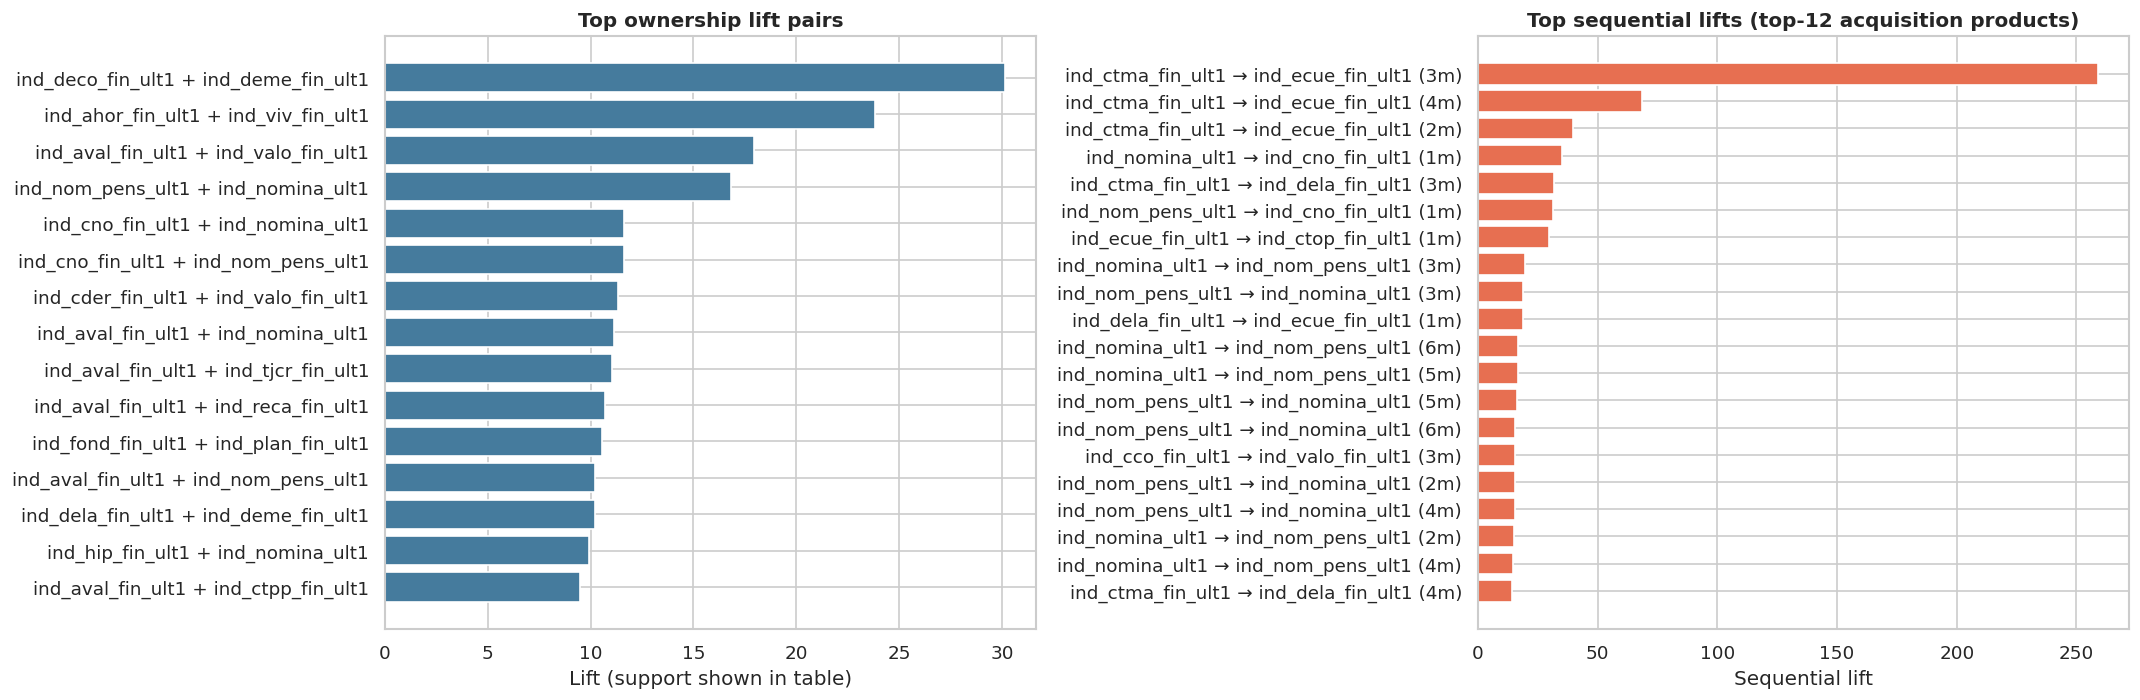

## Product EDA — Feature Candidate Registry

,Feature,Source EDA,Hypothesis,Evidence,Leakage-safe definition,Redundancy concern,Decision
0,product_state_lag1,1.3,state persistence,median P(1|1)=98.80%,state at t-1; valid-gap flag retained,24 state features,INVESTIGATE
1,products_owned_count,3.3,portfolio propensity,rates shown for 16 depth groups,complete product-state count at t-1,overlaps individual lags,INVESTIGATE
2,months_since_last_acquisition,3.1,recency,15 observed recency groups + NULL,last acquisition strictly before t,with recent-count windows,INVESTIGATE
3,acquisitions_last_3m,3.4,recent behavior,rate/support table above,calendar window ending at t-1,1m / 6m windows,INVESTIGATE
4,drops_last_3m,3.5,recent contraction,rate/support table above,calendar window ending at t-1,drop windows,INVESTIGATE
5,pair-affinity features,4.1–4.5,product relationship,166 same-month pairs; sequential table is supp...,only prior product events/states,many sparse pairs,INVESTIGATE


**Block 4 — Findings.** Top same-month pair is ind_cder_fin_ult1 + ind_pres_fin_ult1 with lift 682.64 and joint-event support 1. Pair features are only candidates: require minimum-support thresholds and incremental temporal-validation evidence before inclusion. The registry intentionally contains no final feature decision.

In [30]:
# Result / visualization — EDA 4.1–4.5
# Long tables retain only positive ownership/acquisition rows, which keeps pair joins out-of-core and compact.
OWNERSHIP_EVENTS_PATH = EDA_OUTPUT_DIR / 'product_ownership_positive_eda.parquet'
ACQUISITION_EVENTS_PATH = EDA_OUTPUT_DIR / 'product_acquisition_positive_eda.parquet'

owner_union = ' UNION ALL '.join(
    f"SELECT ncodpers, checkpoint_month, '{p}' AS product FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}') WHERE cur_{p}=1"
    for p in PRODUCT_COLUMNS
)
acq_union = ' UNION ALL '.join(
    f"SELECT ncodpers, checkpoint_month, '{p}' AS product FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}') WHERE acq_{p}=1"
    for p in PRODUCT_COLUMNS
)
con.execute(f"COPY ({owner_union}) TO '{str(OWNERSHIP_EVENTS_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)")
con.execute(f"COPY ({acq_union}) TO '{str(ACQUISITION_EVENTS_PATH)}' (FORMAT PARQUET, COMPRESSION ZSTD)")

ownership_pair = con.execute(f"""
    WITH base AS (
        SELECT COUNT(*)::DOUBLE AS population FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
    ), product_counts AS (
        SELECT product, COUNT(*)::DOUBLE AS product_count
        FROM read_parquet('{str(OWNERSHIP_EVENTS_PATH)}') GROUP BY product
    ), pairs AS (
        SELECT a.product AS product_a, b.product AS product_b, COUNT(*)::BIGINT AS both_count
        FROM read_parquet('{str(OWNERSHIP_EVENTS_PATH)}') a
        JOIN read_parquet('{str(OWNERSHIP_EVENTS_PATH)}') b
          ON a.ncodpers=b.ncodpers AND a.checkpoint_month=b.checkpoint_month AND a.product < b.product
        GROUP BY ALL
    )
    SELECT pairs.*, pa.product_count AS a_count, pb.product_count AS b_count,
           both_count / pa.product_count AS p_b_given_a,
           both_count / pb.product_count AS p_a_given_b,
           (both_count / base.population) / ((pa.product_count / base.population) * (pb.product_count / base.population)) AS lift
    FROM pairs CROSS JOIN base
    JOIN product_counts pa ON pairs.product_a=pa.product
    JOIN product_counts pb ON pairs.product_b=pb.product
    ORDER BY lift DESC, both_count DESC
""").fetchdf()
display(ownership_pair.head(25).style.format({'p_b_given_a':'{:.3%}','p_a_given_b':'{:.3%}','lift':'{:.2f}'}))

same_month_pair = con.execute(f"""
    WITH product_counts AS (
        SELECT product, COUNT(*)::DOUBLE AS event_count
        FROM read_parquet('{str(ACQUISITION_EVENTS_PATH)}') GROUP BY product
    ), pairs AS (
        SELECT a.product AS product_a, b.product AS product_b, COUNT(*)::BIGINT AS both_count
        FROM read_parquet('{str(ACQUISITION_EVENTS_PATH)}') a
        JOIN read_parquet('{str(ACQUISITION_EVENTS_PATH)}') b
          ON a.ncodpers=b.ncodpers AND a.checkpoint_month=b.checkpoint_month AND a.product < b.product
        GROUP BY ALL
    ), total_months AS (
        SELECT COUNT(*)::DOUBLE AS customer_months FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
    )
    SELECT pairs.*, pa.event_count AS a_count, pb.event_count AS b_count,
           both_count / pa.event_count AS p_b_given_a,
           both_count / pb.event_count AS p_a_given_b,
           (both_count / total_months.customer_months) /
             ((pa.event_count / total_months.customer_months) * (pb.event_count / total_months.customer_months)) AS lift
    FROM pairs CROSS JOIN total_months
    JOIN product_counts pa ON pairs.product_a=pa.product
    JOIN product_counts pb ON pairs.product_b=pb.product
    ORDER BY lift DESC, both_count DESC
""").fetchdf()
display(same_month_pair.head(25).style.format({'p_b_given_a':'{:.3%}','p_a_given_b':'{:.3%}','lift':'{:.2f}'}))

# Sequential A→B effects use exact calendar offsets. Each exposure must have a complete
# observed transition at t+k, so both conditional rates and baselines use the same future support.
top_seq_products = con.execute(f"""
    SELECT product FROM read_parquet('{str(ACQUISITION_EVENTS_PATH)}')
    GROUP BY product ORDER BY COUNT(*) DESC LIMIT 12
""").fetchdf()['product'].tolist()
values_sql = ', '.join(f"('{p}')" for p in top_seq_products)
sequential_pair = con.execute(f"""
    WITH selected AS (SELECT * FROM (VALUES {values_sql}) AS t(product)),
    a_events AS (
        SELECT e.* FROM read_parquet('{str(ACQUISITION_EVENTS_PATH)}') e JOIN selected s USING(product)
    ), future_records AS (
        SELECT ncodpers, checkpoint_month
        FROM read_parquet('{str(PRODUCT_HISTORY_EDA_PATH)}')
        WHERE acquisitions_current IS NOT NULL
    ), exposures AS (
        SELECT a.product AS product_a, future.checkpoint_month AS future_month,
               a.ncodpers, gap_months
        FROM a_events a
        CROSS JOIN range(1, 7) AS g(gap_months)
        JOIN future_records future
          ON future.ncodpers=a.ncodpers
         AND future.checkpoint_month = a.checkpoint_month + gap_months * INTERVAL 1 MONTH
    ), b_counts AS (
        SELECT checkpoint_month, product AS product_b, COUNT(*)::DOUBLE AS b_event_count
        FROM read_parquet('{str(ACQUISITION_EVENTS_PATH)}')
        WHERE product IN (SELECT product FROM selected)
        GROUP BY ALL
    ), future_population AS (
        SELECT checkpoint_month, COUNT(*)::DOUBLE AS records FROM future_records GROUP BY checkpoint_month
    ), pair_exposures AS (
        SELECT e.*, s.product AS product_b,
               COALESCE(bc.b_event_count / fp.records, 0) AS baseline_rate,
               (b.ncodpers IS NOT NULL)::INTEGER AS b_after_a
        FROM exposures e
        JOIN selected s ON s.product <> e.product_a
        JOIN future_population fp ON e.future_month=fp.checkpoint_month
        LEFT JOIN b_counts bc ON e.future_month=bc.checkpoint_month AND s.product=bc.product_b
        LEFT JOIN read_parquet('{str(ACQUISITION_EVENTS_PATH)}') b
          ON b.ncodpers=e.ncodpers AND b.checkpoint_month=e.future_month AND b.product=s.product
    )
    SELECT product_a, product_b, gap_months,
           COUNT(*)::BIGINT AS a_event_count,
           SUM(b_after_a)::BIGINT AS b_after_a_count,
           AVG(b_after_a) AS conditional_rate,
           AVG(baseline_rate) AS baseline_b_rate,
           AVG(b_after_a) / NULLIF(AVG(baseline_rate), 0) AS sequential_lift
    FROM pair_exposures
    GROUP BY ALL
    HAVING SUM(b_after_a) > 0
    ORDER BY sequential_lift DESC, b_after_a_count DESC
""").fetchdf()
display(sequential_pair.head(40).style.format({'conditional_rate':'{:.4%}','baseline_b_rate':'{:.4%}','sequential_lift':'{:.2f}'}))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
own_plot = ownership_pair.nlargest(15, 'lift').sort_values('lift')
axes[0].barh(own_plot.product_a + ' + ' + own_plot.product_b, own_plot.lift, color='#457b9d')
axes[0].set(title='Top ownership lift pairs', xlabel='Lift (support shown in table)')
seq_plot = sequential_pair.nlargest(20, 'sequential_lift').sort_values('sequential_lift')
axes[1].barh(seq_plot.product_a + ' → ' + seq_plot.product_b + ' (' + seq_plot.gap_months.astype(str) + 'm)', seq_plot.sequential_lift, color='#e76f51')
axes[1].set(title='Top sequential lifts (top-12 acquisition products)', xlabel='Sequential lift')
plt.tight_layout(); plt.show()

# Final registry: evidence fields are populated from computed tables; all EDA decisions remain provisional.
registry = pd.DataFrame([
    ['product_state_lag1', '1.3', 'state persistence', f"median P(1|1)={transition_summary_113.p_state_1_given_prior_1.median():.2%}", 'state at t-1; valid-gap flag retained', '24 state features', 'INVESTIGATE'],
    ['products_owned_count', '3.3', 'portfolio propensity', f"rates shown for {len(portfolio_future):,} depth groups", 'complete product-state count at t-1', 'overlaps individual lags', 'INVESTIGATE'],
    ['months_since_last_acquisition', '3.1', 'recency', f"{len(recency_future):,} observed recency groups + NULL", 'last acquisition strictly before t', 'with recent-count windows', 'INVESTIGATE'],
    ['acquisitions_last_3m', '3.4', 'recent behavior', 'rate/support table above', 'calendar window ending at t-1', '1m / 6m windows', 'INVESTIGATE'],
    ['drops_last_3m', '3.5', 'recent contraction', 'rate/support table above', 'calendar window ending at t-1', 'drop windows', 'INVESTIGATE'],
    ['pair-affinity features', '4.1–4.5', 'product relationship', f"{len(same_month_pair):,} same-month pairs; sequential table is support-limited", 'only prior product events/states', 'many sparse pairs', 'INVESTIGATE'],
], columns=['Feature','Source EDA','Hypothesis','Evidence','Leakage-safe definition','Redundancy concern','Decision'])
display(Markdown('## Product EDA — Feature Candidate Registry'))
display(registry)

top_pair = same_month_pair.iloc[0] if len(same_month_pair) else None
pair_sentence = (
    f"Top same-month pair is {top_pair.product_a} + {top_pair.product_b} with lift {top_pair.lift:.2f} "
    f"and joint-event support {top_pair.both_count:,}."
    if top_pair is not None else "No same-month acquisition pair had positive support."
)
display(Markdown(
    f"**Block 4 — Findings.** {pair_sentence} Pair features are only candidates: require minimum-support "
    f"thresholds and incremental temporal-validation evidence before inclusion. The registry intentionally "
    f"contains no final feature decision."
))

In [35]:
# Compact evidence extraction from executed Section 11 objects.
summary_evidence = {
    'state_top': latest_ownership.iloc[0][['product','ownership_rate','customers_holding','observed_state_count']].to_dict(),
    'state_median_persistence': float(transition_summary_113.p_state_1_given_prior_1.median()),
    'state_lowest_persistence': transition_summary_113.loc[
        transition_summary_113.p_state_1_given_prior_1.idxmin(),
        ['product','p_state_1_given_prior_1','prior_1_count']
    ].to_dict(),
    'event_top': imbalance_by_product.iloc[0][['product','acquisition_rate','eligible','acquisitions','negative_to_positive_ratio']].to_dict(),
    'multi_acquisition_rate': float(acquisitions_per_customer_month.loc[acquisitions_per_customer_month.acquisitions_current.gt(1), 'records'].sum() / acquisitions_per_customer_month.records.sum()),
    'recency_peak': recency_future.loc[
        recency_future.future_acquisition_rate.idxmax(),
        ['feature_value','records','future_acquisition_count','future_acquisition_rate']
    ].to_dict(),
    'never_acquired': never_acquired_future.iloc[0][['records','future_acquisition_count','future_acquisition_rate']].to_dict(),
    'portfolio_0': portfolio_future.loc[portfolio_future.feature_value.eq(0)].iloc[0][['records','future_acquisition_rate']].to_dict(),
    'portfolio_5': portfolio_future.loc[portfolio_future.feature_value.eq(5)].iloc[0][['records','future_acquisition_rate']].to_dict(),
    'same_month_top': same_month_pair.iloc[0][['product_a','product_b','both_count','lift']].to_dict(),
    'ownership_high_support': ownership_pair.loc[ownership_pair.both_count.idxmax(), ['product_a','product_b','both_count','lift']].to_dict(),
}
summary_evidence

{'state_top': {'product': 'ind_cco_fin_ult1',
  'ownership_rate': 0.6029450761337395,
  'customers_holding': 561615,
  'observed_state_count': 931453},
 'state_median_persistence': 0.9879869185163583,
 'state_lowest_persistence': {'product': 'ind_deco_fin_ult1',
  'p_state_1_given_prior_1': 0.7328546980005843,
  'prior_1_count': 23957},
 'event_top': {'product': 'ind_cco_fin_ult1',
  'acquisition_rate': 0.016073018109620668,
  'eligible': 4299317,
  'acquisitions': 69103,
  'negative_to_positive_ratio': 61.21606876691316},
 'multi_acquisition_rate': 0.007168743661986061,
 'recency_peak': {'feature_value': 3,
  'records': 264149,
  'future_acquisition_count': 50314,
  'future_acquisition_rate': 0.1904758299293202},
 'never_acquired': {'records': 10837334,
  'future_acquisition_count': 201761,
  'future_acquisition_rate': 0.01861721711262198},
 'portfolio_0': {'records': 2291853,
  'future_acquisition_rate': 0.014994417181206648},
 'portfolio_5': {'records': 271830,
  'future_acquisition

## 11.6 Insights from executed outputs

### Block 1 — Product state

- At the latest checkpoint (2016-05-28), `ind_cco_fin_ult1` has the highest ownership: **561,615 / 931,453** observed customer states (**60.295%**). Ownership is highly concentrated, so product-level popularity should be retained as context rather than treating all products alike.
- The median state-persistence rate (P(State_t=1\mid State_{t-1}=1)) across 24 products is **98.799%**. The lowest is `ind_deco_fin_ult1` at **73.285%** over **23,957** prior-owner transitions. Lagged state is therefore a strong candidate for state modelling and for determining acquisition eligibility; it must not be used as the same-month acquisition label.

### Block 2 — Product events

- `ind_cco_fin_ult1` has the highest observed 0→1 acquisition rate: **69,103 / 4,299,317 = 1.607%**, or roughly **61.2 negatives per positive**. Acquisition remains rare even for the most acquired product, supporting product-specific class weighting or sampling.
- Multi-product acquisition occurs in only **0.717%** of complete customer-month transitions. Same-month pair features may be investigated, but they should not be assumed to dominate the recommendation model.

### Block 3 — Historical behavior

- Future any-acquisition rate is **19.048%** at recency 3 months (**50,314 / 264,149** records), compared with **1.862%** for the never-acquired group (**201,761 / 10,837,334**). This is an association, not a causal effect, but supports `months_since_last_acquisition` and an explicit never-acquired state/missing treatment.
- Prior portfolio depth is associated with future acquisition: **1.499%** for 0 products (**2,291,853** records) versus **11.673%** for 5 products (**271,830** records). The small high-depth tails still need minimum-support checks and temporal validation.
- Recent 3-month and 6-month acquisition counts have rank correlation **0.650**. Keep both as candidates initially, then use temporal validation to decide whether one is redundant.

### Block 4 — Product relationships

- The largest ownership co-occurrence support is `ind_cco_fin_ult1 + ind_ctop_fin_ult1`: **1,162,311** joint states, but lift is only **1.007**—consistent with co-occurrence largely explained by popularity.
- The top same-month acquisition lift is `ind_cder_fin_ult1 + ind_pres_fin_ult1` at **682.64**, but it has only **1** joint event. It is **not actionable** as a feature without a minimum-support threshold; high lift alone is insufficient evidence.

### Recommended next step

Use these as provisional EDA candidates only: lagged product states, portfolio depth, acquisition recency, and selected recent-acquisition windows. Compare them with a time-based validation design; do not promote sparse pairwise features without support and incremental validation evidence.